# LipSyncNet — Training (Kaggle committed-run ready)

This notebook trains LipSyncNet (LSN) end-to-end on Kaggle and is designed to run as a committed (**Save & Run All**) job.

**Key engineering changes vs. the original training harness**:
- Full training state (model + optimizer + scaler + `best_val_loss` + `history`) is saved in a single self-describing checkpoint.
- `last_checkpoint.pt` is pushed to HuggingFace Hub **every epoch**, so if the ~9h Kaggle commit timeout kills the run, the next commit resumes cleanly — with `best_val_loss` intact.
- Mixed-precision training (AMP) for ~1.5–2× speedup on T4 and ~40% less VRAM.
- `cudnn.benchmark=True`, larger `num_workers`, persistent workers, and gradient accumulation for an effective batch size of 8.
- Frozen BatchNorm layers are kept in eval mode so their running stats don't drift on small batches.
- Resume logic tries HF Hub first, then local, then fresh — no hardcoded epoch numbers to edit between runs.

**Architecture is unchanged** from the original notebook.

**NOTES**  
[1] The paper reports total=307,595,340 / trainable=304,824,800 / frozen=2,780,531.

- Frozen-param count (2,780,531) does not correspond to any stage boundary in torchvision EfficientNet-B0.  
  Actual cumulative counts:
  - stages 0-5 frozen -> 851,808
  - stages 0-6 frozen -> 2,878,156 <- closest to paper's 2,780,531
  - stages 0-7 frozen -> 3,595,388

  No boundary equals 2,780,531 exactly.  The paper was built in TensorFlow/Keras, whose EfficientNet weight layout differs slightly from torchvision's.  We use stages 0-6 frozen (2,878,156), which is the closest achievable clean boundary and matches the original code's behavior.

- LSTM parameter counts in Table 1 are conflicting with the stated architecture.  A PyTorch BiLSTM(input=70912, hidden=512) has ~292M parameters, not the paper's 5,971,968.

  Reverse-engineering:
  - 5,971,968 / 2 dirs = 2,985,984 per direction
  - Solving 4*(inp*512 + 512^2 + 2*512) = 2,985,984  ->  inp ≈ 944
  - No architecturally meaningful input dimension produces this.
  - The LSTM-2 value (10,485,760) back-solves to inp=2,046 (hid=512) or inp=254 (hid=1,024) — neither matches the stated architecture.

[2] Regarding Self-Attention:  
Figure 9 (block diagram) shows a self-attention layer between Bi-LSTM-2 and the output. Table 1 has no corresponding row, states no configuration (heads, d_model, dropout), and the cumulative parameter count in Table 1 leaves no room for it. See code block for more context.

In [ ]:
from __future__ import annotations

import os
import math
import time
import shutil
import random
import string
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from tqdm import tqdm


import json
from time import perf_counter

In [ ]:
!pip install -q huggingface_hub

In [ ]:
# cuDNN autotune — inputs are fixed shape (B, 75, 46, 140), so benchmark wins.
# Note: this makes conv algorithms non-deterministic. Acceptable for training;
# set to False if you need bitwise-reproducible runs for a paper table.
torch.backends.cudnn.benchmark = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")
if device.type == "cuda":
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        print(f"  cuda:{i} = {p.name}, {p.total_memory/1e9:.1f} GB")


device: cuda
  cuda:0 = Tesla T4, 15.6 GB


In [ ]:
class Conv3DBlock(nn.Module):
    """Single conv3d + BN + ReLU + MaxPool block."""

    def __init__(self,
                 in_channels:  int,
                 out_channels: int,
                 kernel_size:  tuple,
                 padding:      tuple,
                 pool_kernel:  tuple = (1, 2, 2),
                 pool_stride:  tuple = (1, 2, 2)):
        super().__init__()
        self.conv = nn.Conv3d(in_channels, out_channels,
                              kernel_size=kernel_size,
                              padding=padding,
                              bias=False)
        self.bn   = nn.BatchNorm3d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool3d(kernel_size=pool_kernel, stride=pool_stride)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.pool(self.relu(self.bn(self.conv(x))))

In [ ]:
class Frontend3DCNN(nn.Module):
    """
    Four-block 3D-CNN front-end (Table 1).

    Input : (B, 1, T, 46, 140)
    Output: (B, T, 8192) -- 512 * 2 * 8 per timestep

    Block  filters  kernel    padding   pool(1,2,2)   spatial out
    ──────────────────────────────────────────────────────────────
      1      64    (3,5,5)   (1,2,2)    (1,2,2)       23 * 70
      2     128    (3,5,5)   (1,2,2)    (1,2,2)       11 * 35
      3     256    (3,3,3)   (1,1,1)    (1,2,2)        5 * 17
      4     512    (3,3,3)   (1,1,1)    (1,2,2)        2 *  8     -> flat 8,192
    """

    OUT_C    = 512
    OUT_H    = 2
    OUT_W    = 8
    FLAT_DIM = OUT_C * OUT_H * OUT_W   # 8,192

    def __init__(self):
        super().__init__()
        self.block1 = Conv3DBlock(1,   64,  (3, 5, 5), (1, 2, 2))
        self.block2 = Conv3DBlock(64,  128, (3, 5, 5), (1, 2, 2))
        self.block3 = Conv3DBlock(128, 256, (3, 3, 3), (1, 1, 1))
        self.block4 = Conv3DBlock(256, 512, (3, 3, 3), (1, 1, 1))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)                          # (B,  64, T, 23, 70)
        x = self.block2(x)                          # (B, 128, T, 11, 35)
        x = self.block3(x)                          # (B, 256, T,  5, 17)
        x = self.block4(x)                          # (B, 512, T,  2,  8)
        B, C, T, Hf, Wf = x.shape
        x = x.permute(0, 2, 1, 3, 4).contiguous()  # (B, T, C, Hf, Wf)
        return x.view(B, T, C * Hf * Wf)           # (B, T, 8192)


In [ ]:
class EfficientNet(nn.Module):
    """
    EfficientNet-B0 feature extractor, applied frame-by-frame.

    Input : (B*T, 1, H, W) -- raw grayscale lip frames (NOT 3D-CNN output)
    Output: (B*T, 62720)   -- flattened spatial map (1280 * 7 * 7)

    Freezing policy [D1]:
        Freeze features[0..6] -> 2,878,156 frozen params.
        Unfreeze features[7,8] -> trained end-to-end.

        The paper states 2,780,531 frozen, which no torchvision stage boundary produces.
        The 97,625-param discrepancy is attributed to TF/Keras vs. torchvision weight layout differences.
    """

    FEATURE_DIM = 7 * 7 * 1280   # 62,720

    def __init__(self, freeze_early: bool = True):
        super().__init__()
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.features = base.features   # indices 0-8; output (B, 1280, 7, 7)

        if freeze_early:
            # Freeze all parameters first
            for param in self.features.parameters():
                param.requires_grad = False
            # Unfreeze stages 7 and 8 (last two MBConv blocks + head)
            for stage_idx in (7, 8):
                for param in self.features[stage_idx].parameters():
                    param.requires_grad = True

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.expand(-1, 3, -1, -1)                            # (B*T, 3, H, W)
        x = F.interpolate(x, size=(224, 224),
                          mode="bilinear", align_corners=False)  # (B*T, 3, 224, 224)
        x = self.features(x)                                    # (B*T, 1280, 7, 7)
        return torch.flatten(x, 1)                              # (B*T, 62720)

In [ ]:
class BiLSTMBackend(nn.Module):
    """
    2* Bi-LSTM with input projection and dropout.
    Used inside LipSyncNetVariant — NOT inside LipSyncNetPaper.

    input_dim -> Linear(1024) -> BiLSTM(512*2) -> Dropout -> BiLSTM(512*2) -> Dropout
    Output dim: 1,024.
    """

    def __init__(self, input_dim: int, hidden: int = 512, dropout: float = 0.5):
        super().__init__()
        self.out_dim    = hidden * 2
        self.input_proj = nn.Linear(input_dim, self.out_dim)
        self.lstm1      = nn.LSTM(self.out_dim, hidden, batch_first=True,
                                  bidirectional=True)
        self.drop1      = nn.Dropout(dropout)
        self.lstm2      = nn.LSTM(self.out_dim, hidden, batch_first=True,
                                  bidirectional=True)
        self.drop2      = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x, _ = self.lstm1(self.input_proj(x))
        x     = self.drop1(x)
        x, _ = self.lstm2(x)
        return self.drop2(x)


class IdentityBackend(nn.Module):
    """
    No temporal modeling — ablation baseline.
    Passes fused features directly to the classifier unchanged.
    Isolates the contribution of the temporal backend.
    """

    def __init__(self, input_dim: int, **_):
        super().__init__()
        self.out_dim = input_dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x


class _SinusoidalPE(nn.Module):
    """Fixed sinusoidal positional encoding ("Attention Is All You Need" paper; Vaswani et al., 2017)."""

    def __init__(self, d_model: int, max_len: int = 75, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float)
                        * (-math.log(10_000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(x + self.pe[:, :x.size(1)])


class TransformerBackend(nn.Module):
    """
    2-layer bidirectional Transformer encoder.
    Linear projection -> sinusoidal PE -> 2* TransformerEncoderLayer.
    Output dim: d_model (default 1,024).

    NOTE: max_len in _SinusoidalPE must be >= the longest sequence T in the dataset;
    Update if LRS2 clips exceed 75 frames (see TODO-PRE-5).
    """

    def __init__(self, input_dim: int, d_model: int = 1024,
                 nhead: int = 4, num_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.out_dim    = d_model
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_enc    = _SinusoidalPE(d_model, dropout=dropout)
        self.encoder    = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                       dim_feedforward=d_model * 4,
                                       dropout=dropout, batch_first=True),
            num_layers=num_layers,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(self.pos_enc(self.input_proj(x)))


_BACKEND_REGISTRY: dict[str, type] = {
    "bilstm":      BiLSTMBackend,
    "identity":    IdentityBackend,
    "transformer": TransformerBackend,
}


In [ ]:
# ============================================================
# TransformerBackendPerStream — matches friend's transformer variant
# ============================================================
# Per-stream projection (CNN and EfficientNet streams each get their
# own Linear+LayerNorm to d_model/2), then concat, then standard
# transformer encoder. Different parameter budget and inductive bias
# than our single-projection TransformerBackend, but architecturally
# clean.

class TransformerBackendPerStream(nn.Module):
    """
    Forward path:
        cnn (B, T, 8192)   -> Linear(8192, proj_dim) -> LayerNorm(proj_dim)
        eff (B, T, 62720)  -> Linear(62720, proj_dim) -> LayerNorm(proj_dim)
        concat along last dim                                  -> (B, T, d_model)
        sinusoidal PE (additive)                               -> (B, T, d_model)
        TransformerEncoder (num_layers layers)                 -> (B, T, d_model)

    Requires d_model == 2 * proj_dim (the two streams concat).

    Matches state-dict keys:
        backend.cnn_proj.{0.weight, 0.bias, 1.weight, 1.bias}
        backend.eff_proj.{0.weight, 0.bias, 1.weight, 1.bias}
        backend.encoder.layers.{L}.*
        backend.pos_enc.pe
    """

    # Input dims coming from the frontend (do NOT make these configurable —
    # they're determined by the upstream 3D-CNN and EfficientNet-B0 outputs).
    CNN_DIM = Frontend3DCNN.FLAT_DIM      # 8,192
    EFF_DIM = EfficientNet.FEATURE_DIM    # 62,720

    def __init__(self,
                 input_dim: int = None,       # ignored; kept for registry compat
                 d_model:   int = 1024,
                 nhead:     int = 4,          # TODO: confirm with friend
                 num_layers: int = 2,
                 dropout:    float = 0.1):
        super().__init__()

        assert d_model % 2 == 0, f"d_model ({d_model}) must be even (two streams concat)"
        proj_dim = d_model // 2                # 512 for d_model=1024

        self.out_dim = d_model

        # Per-stream projection + LayerNorm
        self.cnn_proj = nn.Sequential(
            nn.Linear(self.CNN_DIM, proj_dim),
            nn.LayerNorm(proj_dim),
        )
        self.eff_proj = nn.Sequential(
            nn.Linear(self.EFF_DIM, proj_dim),
            nn.LayerNorm(proj_dim),
        )

        # Reuse the existing _SinusoidalPE from the notebook.
        self.pos_enc = _SinusoidalPE(d_model, dropout=dropout)

        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=dropout, batch_first=True,
            ),
            num_layers=num_layers,
        )

    def forward(self, fused: torch.Tensor) -> torch.Tensor:
        """
        IMPORTANT: unlike the other backends in the registry, this one does
        NOT take the already-fused (B, T, 70912) tensor as input. It needs
        the two streams separately. LipSyncNetVariant currently fuses before
        calling the backend — we handle this by splitting fused back into
        its two components. Feasible because fused is just concat([cnn, eff])
        along the last dim in a known order.
        """
        cnn = fused[..., :self.CNN_DIM]                                # (B, T, 8192)
        eff = fused[..., self.CNN_DIM:self.CNN_DIM + self.EFF_DIM]     # (B, T, 62720)

        cnn_out = self.cnn_proj(cnn)      # (B, T, d_model/2)
        eff_out = self.eff_proj(eff)      # (B, T, d_model/2)

        x = torch.cat([cnn_out, eff_out], dim=-1)    # (B, T, d_model)
        x = self.pos_enc(x)
        return self.encoder(x)

In [ ]:
# Register the per-stream transformer variant so build_variant() can find it.
_BACKEND_REGISTRY["transformer_perstream"] = TransformerBackendPerStream

In [ ]:
class SelfAttentionBlock(nn.Module):
    """
    Post-norm multi-head self-attention block placed between Bi-LSTM-2 and
    the classifier, as shown in Figure 9 of the paper.

    Design rationale (all choices forced by context; none are free):

    embed_dim = 1024
        Forced by the Bi-LSTM-2 output shape (B, T, 1024) and the classifier
        input shape (B, T, 1024).  The block must be dimensionality-preserving.

    num_heads = 8
        8 heads * 128 head_dim = 1024.

    Residual connection  (out = LayerNorm(x + Dropout(MHA(x))))
        Standard post-norm formulation.  A bare MHA call with no residual
        would discard positional information accumulated by the LSTMs and
        is not used anywhere in the sequence modelling literature at this
        position.  The paper does not specify, so the conventional choice
        is made and documented.

    dropout = 0.1
        The paper states no dropout for this layer.  0.1 is the standard
        attention dropout used in the original Transformer (Vaswani et al.).
        Keeping it low (vs. the 0.5 used in the LSTM stack) because attention
        weights are already an implicit regulariser. It is configurable.

    No feedforward sublayer
        The paper's block diagram shows a single "Self-Attention" box,
        use TransformerBackend instead during ablation.
    """

    def __init__(self, embed_dim: int = 1024, num_heads: int = 8,
                 dropout: float = 0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(embed_dim=embed_dim,
                                           num_heads=num_heads,
                                           dropout=dropout,
                                           batch_first=True)
        self.norm  = nn.LayerNorm(embed_dim)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor,
                key_padding_mask: torch.Tensor | None = None) -> torch.Tensor:
        # query = key = value = x  (self-attention over the temporal dimension)
        attn_out, _ = self.attn(x, x, x,
                                key_padding_mask=key_padding_mask,
                                need_weights=False)
        # Post-norm residual:  LayerNorm(x + Dropout(Attn(x)))
        return self.norm(x + self.drop(attn_out))              # (B, T, 1024)


In [ ]:
class LipSyncNetPaper(nn.Module):
    """
    Re-implementation of LipSyncNet (Table 1 / Figure 8 & 9).

    Explicit decisions for all ambiguities:
      [1] EfficientNet: stages 0-6 frozen (2,878,156 params; closest to paper).
      [2] Self-attention included (Figure 9), implemented as SelfAttentionBlock
           (embed_dim=1024, num_heads=8).  Absent from Table 1.
           Controlled by `use_self_attn` flag so the no-attention variant (matching Table 1) can still be instantiated for ablation.
      [3] No input projection before LSTM-1; raw 70,912-dim concat fed directly.
    """

    CNN_DIM   = Frontend3DCNN.FLAT_DIM              # 8,192
    EFF_DIM   = EfficientNet.FEATURE_DIM      # 62,720
    FUSED_DIM = CNN_DIM + EFF_DIM                   # 70,912

    def __init__(self,
                 vocab_size:          int  = 40,
                 freeze_early_effnet: bool = True,
                 use_self_attn:       bool = True):
        """
        Args:
            vocab_size          : output classes excluding CTC blank.
            freeze_early_effnet : freeze EfficientNet stages 0-6.
            use_self_attn       : include SelfAttentionBlock after Bi-LSTM-2.
        """
        super().__init__()
        self.vocab_size    = vocab_size
        self.use_self_attn = use_self_attn

        self.cnn3d        = Frontend3DCNN()
        self.efficientnet = EfficientNet(freeze_early=freeze_early_effnet)

        self.lstm1 = nn.LSTM(self.FUSED_DIM, 512, batch_first=True,
                             bidirectional=True)
        self.drop1 = nn.Dropout(0.5)
        self.lstm2 = nn.LSTM(1024, 512, batch_first=True, bidirectional=True)
        self.drop2 = nn.Dropout(0.5)

        if use_self_attn:
            self.self_attn = SelfAttentionBlock(embed_dim=1024, num_heads=8,
                                                dropout=0.1)

        self.classifier = nn.Linear(1024, vocab_size + 1)  # +1 = CTC blank

    def forward(self, x: torch.Tensor,
                key_padding_mask: torch.Tensor | None = None) -> torch.Tensor:
        B, T, H, W = x.shape

        # 3D-CNN branch (spatiotemporal)
        cnn_out = self.cnn3d(x.unsqueeze(1))           # (B, T, 8192)

        # EfficientNet branch (per-frame, on raw input)
        frames  = x.view(B * T, 1, H, W)               # (B*T, 1, 46, 140)
        eff_out = self.efficientnet(frames)             # (B*T, 62720)
        eff_out = eff_out.view(B, T, self.EFF_DIM)     # (B, T, 62720)

        fused = torch.cat([cnn_out, eff_out], dim=-1)  # (B, T, 70912)

        # Bi-LSTM back-end
        out, _ = self.lstm1(fused)                     # (B, T, 1024)
        out     = self.drop1(out)
        out, _ = self.lstm2(out)                       # (B, T, 1024)
        out     = self.drop2(out)

        # Skipped when use_self_attn=False.
        if self.use_self_attn:
            out = self.self_attn(out, key_padding_mask=key_padding_mask)
                                                       # (B, T, 1024)
        # Classifier
        logits    = self.classifier(out)               # (B, T, vocab+1)
        log_probs = F.log_softmax(logits, dim=-1)
        return log_probs.permute(1, 0, 2)              # (T, B, vocab+1)


In [ ]:
class LipSyncNetVariant(nn.Module):
    """
    Backend selected at construction from {"bilstm", "transformer", "identity"}.

    Note: All backends receive the raw FUSED_DIM (70,912) vector for fair comparison.
    The BiLSTM variant adds a projection (Linear 70912 -> 1024) before the LSTMs;
    this differs slightly from LipSyncNetPaper (i.e., no projection).
    For paper: Both should be reported with the distinction made explicit.
    """

    CNN_DIM   = Frontend3DCNN.FLAT_DIM          # 8,192
    EFF_DIM   = EfficientNet.FEATURE_DIM  # 62,720
    FUSED_DIM = CNN_DIM + EFF_DIM               # 70,912

    def __init__(self,
                 backend:             str  = "bilstm",
                 vocab_size:          int  = 40,
                 freeze_early_effnet: bool = True,
                 **backend_kwargs):
        super().__init__()

        if backend not in _BACKEND_REGISTRY:
            raise ValueError(
                f"Unknown backend '{backend}'. "
                f"Valid options: {list(_BACKEND_REGISTRY)}")

        self.vocab_size   = vocab_size
        self.cnn3d        = Frontend3DCNN()
        self.efficientnet = EfficientNet(freeze_early=freeze_early_effnet)
        self.backend      = _BACKEND_REGISTRY[backend](
                                input_dim=self.FUSED_DIM, **backend_kwargs)
        self.classifier   = nn.Linear(self.backend.out_dim, vocab_size + 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, H, W = x.shape

        cnn_out = self.cnn3d(x.unsqueeze(1))

        frames  = x.view(B * T, 1, H, W)

        eff_out = self.efficientnet(frames).view(B, T, self.EFF_DIM)

        fused   = torch.cat([cnn_out, eff_out], dim=-1)   # (B, T, 70912)

        out       = self.backend(fused)

        logits    = self.classifier(out)
        log_probs = F.log_softmax(logits, dim=-1)

        return log_probs.permute(1, 0, 2)                 # (T, B, vocab+1)

In [ ]:
def build_paper_model(vocab_size:    int  = 40,
                      use_self_attn: bool = False,
                      device:        str  = "cpu") -> LipSyncNetPaper:
    """Instantiate the paper-exact LipSyncNetPaper model."""
    return LipSyncNetPaper(vocab_size=vocab_size,
                           use_self_attn=use_self_attn).to(device)


def build_variant(backend:    str = "bilstm",
                  vocab_size: int = 40,
                  device:     str = "cpu",
                  **backend_kwargs) -> LipSyncNetVariant:
    """
    Instantiate a variant model with the chosen temporal backend.
    """
    return LipSyncNetVariant(backend=backend,
                             vocab_size=vocab_size,
                             **backend_kwargs).to(device)


def count_parameters(model: nn.Module) -> dict[str, int]:
    """Return total, trainable, and frozen parameter counts."""
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"total": total, "trainable": trainable, "frozen": total - trainable}

In [ ]:
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device : {device}\n")

    dummy = torch.randn(2, 75, 46, 140).to(device)

    # Paper model
    paper = build_variant(backend="identity", device=device)
    ps    = count_parameters(paper)
    with torch.no_grad():
        po = paper(dummy)

    # Guard: identity variant must contain zero LSTM modules.
    n_lstm = sum(1 for m in paper.modules() if isinstance(m, nn.LSTM))
    assert n_lstm == 0, f"Expected 0 LSTM modules, found {n_lstm}"

    _pcount = count_parameters(paper)
    print(f"[identity] total={_pcount['total']:,}  "
      f"trainable={_pcount['trainable']:,}  frozen={_pcount['frozen']:,}")

Device : cuda

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 228MB/s]


[identity] total=11,959,781  trainable=9,081,625  frozen=2,878,156



# TODO: PREPROCESSING

## TODO-PRE-1  [GRID — paper-subset split for exact reproduction]
- Reproduce the paper's 450 train / 550 test split from a ~1,000 video subset.  The paper does not state which speaker(s) or random seed.
- Adopt seed=42, sample from a single speaker, and document the choice.
- This run targets 96.7% accuracy / 8.2% WER.  Report honestly — do NOT tune the split to match the paper's numbers post-hoc.

## TODO-PRE-2  [GRID — full-dataset split]
- After the paper-subset reproduction, define a speaker-independent split:
- 3 speakers for test, 2 for val, 28 for train.  Report on this split in a separate table clearly labelled "GRID-full".

## TODO-PRE-3  [LRS2 — access]
- Use the official pre-train / train / val / test splits verbatim.
- Do NOT resplit; published baselines use these exact splits.

## TODO-PRE-4  [LRS2 — variable-length handling]
- LRS2 clips vary in length; the model currently assumes fixed T=75.
- Steps:
  - Compute the length distribution over the training set. Choose MAX_T = 95th-percentile clip length (avoids memory blow-up from outliers while preserving most content).
  - Pad shorter clips to MAX_T with zero frames; record true lengths.
  - Pass true lengths as `input_lengths` to CTCLoss — padding frames must NOT contribute to the CTC loss.
  - Update _SinusoidalPE(max_len=MAX_T) in TransformerBackend if MAX_T > 75.
  - 3D-CNN is fully convolutional in T and handles any T >= 3.

## TODO-PRE-5  [ROI extraction — verify consistency with paper]
The preprocessing script must:
- Use dlib 68-point landmarks to crop the lip region.
- Output exactly (H=46, W=140) — landscape orientation, H < W.
- Convert to grayscale before normalization.
- Normalize PER VIDEO: subtract video mean, divide by video std. (NOT per-dataset)
- Save pre-cropped tensors to disk (e.g., .npy or .pt) so ROI detection runs once, not every epoch.

## TODO-PRE-6  [Vocabulary — verify label mapping before ANY training]
- Paper vocabulary: 40 symbols = {space, a-z, ?, !, ', 1-9}
- Index 0    : CTC blank (PyTorch CTCLoss convention)
- Index 1-40 : the 40 symbols in a fixed, documented order
- Write a unit test: encode a known sentence -> decode -> assert round-trip. A mismatch here produces plausible-looking loss curves but wrong text.

# TODO-PRE-8  [Alignment files — silence handling]
- GRID .align files mark silence as 'sil'.  The paper excludes silence.
- Verify preprocessing strips 'sil' tokens and that all remaining label sequences are non-empty for every retained sample.

# TODO-PRE-9  [Data augmentation — training split only]
Paper mentions augmentation without specifying transforms.
- Implement and apply ONLY during training (never val or test):
- Horizontal flip (p=0.5)
- Random time crop: sample T consecutive frames when clip > T frames
- Brightness/contrast jitter: ±20%
- For LRS2, also consider: random rectangular erasing over lip area (p=0.1)?



# TODO: TRAINING

## TODO-TRN-1  [CTCLoss setup]
- loss_fn = torch.nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)
- zero_infinity=True suppresses -inf on degenerate short sequences and prevents NaN gradients in early training — essential for stability.

- Call signature:
	- loss = loss_fn(log_probs, targets, input_lengths, target_lengths)

- For fixed-T GRID: input_lengths = torch.full((B,), T, dtype=torch.long)

## TODO-TRN-2  [Gradient clipping]
- Bi-LSTMs on CTC are prone to explosion; the paper is silent on clipping.
- After loss.backward(), before optimizer.step(): grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
- Log grad_norm each epoch; if it regularly saturates at 5.0, lower max_norm.

## TODO-TRN-3  [Batch size — unreported by paper; must be chosen and documented]
- The paper model has ~292M parameters in LSTM-1 alone and is very memory heavy.  Start with batch_size=2 on a single GPU. Use gradient accumulation to reach an effective batch of 8-16:
- loss = loss / accumulation_steps # accumulate for N steps, then: optimizer.step(); optimizer.zero_grad()
- Report batch_size and effective_batch in all experiment tables.

## TODO-TRN-4  [Training harness — single unified entry point]
- Build train.py with argparse flags:
* `--model` - {paper, bilstm, transformer, identity}
* `--dataset` - {grid_subset, grid_full, lrs2}
* `--epochs` - int - (default 100, matching paper)
* `--lr`- float (default 1e-4, fixed — no LR schedule per paper)
* `--batch` - int
* `--accum` - int - (gradient accumulation steps, default 1)
* `--seed` - int - (default 42)
* `--resume` - str - (path to checkpoint, optional)
- All four model conditions MUST use identical hyperparameters for a valid comparison.

## TODO-TRN-5  [Checkpointing]
- Save every 10 epochs AND whenever val_loss improves.
- Checkpoint dict must contain:
	- {epoch, model_state_dict, optimizer_state_dict, val_loss, val_wer, config}, where config captures all argparse arguments so checkpoints are self-describing and runs are fully reproducible from a checkpoint.

## TODO-TRN-6  [Logging]
- Log per epoch: train_loss, val_loss, val_WER, grad_norm, epoch_time_sec.
- Use torch.utils.tensorboard.SummaryWriter or wandb.
- Export loss-vs-epoch curves as static images for the capstone report (reproducing Figures 13 and 14 style from the paper?)

## TODO-TRN-7  [LRS2 training strategy — decide before starting]
LRS2 labelled train split is small (~1,166 utterances); from-scratch training will likely underfit.

Suggestion:
- Phase 1: Train on GRID-full for 100 epochs -> save best checkpoint.
- Phase 2: Load GRID checkpoint; fine-tune on LRS2.  Optionally, freeze 3D-CNN for first 10 LRS2 epochs, then unfreeze.
- Document the chosen strategy explicitly; report which GRID epoch was used to initialize.

## TODO-TRN-8  [Reproducibility — mandatory before any training run]
At the top of train.py:
- import random, numpy as np
- random.seed(seed); np.random.seed(seed)
- torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
- torch.backends.cudnn.deterministic = True
- torch.backends.cudnn.benchmark-   = False

Log and include in capstone appendix:
- Python version, PyTorch version, CUDA version,
- torchvision version, GPU model and VRAM.


## Training Setup

In [ ]:
# SETUP Configuration
NUM_FRAMES      = 75                # temporal depth of each video clip
FRAME_H         = 46                # frame height (pixels)
FRAME_W         = 140               # frame width  (pixels)
IN_CHANNELS     = 1                 # grayscale input

VOCAB_SIZE      = 40                # distinct characters
BLANK_INDEX     = 0                 # CTC blank token index (PyTorch CTCLoss convention: blank=0)
NUM_CLASSES     = VOCAB_SIZE + 1    # 41 output units (incl. blank)

EFFICIENTNET_H  = 224
EFFICIENTNET_W  = 224

LSTM_UNITS      = 512               # units per direction; 512×2 = 1024 output
DROPOUT_RATE    = 0.5
LEARNING_RATE   = 1e-4
BEAM_WIDTH      = 100

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# grid labels are lowercase english words + spaces
VOCAB = [' '] + list(string.ascii_lowercase)

# ids start at 1 (0 is reserved for ctc blank)
char_to_idx = {ch: i + 1 for i, ch in enumerate(VOCAB)}
idx_to_char = {i + 1: ch for i, ch in enumerate(VOCAB)}

VOCAB_SIZE = len(VOCAB)
NUM_CLASSES = VOCAB_SIZE + 1  # includes blank

print("vocab size:", VOCAB_SIZE)
print("num classes:", NUM_CLASSES)
print("blank index:", BLANK_INDEX)
print("sample mapping:", {k: char_to_idx[k] for k in [' ', 'a', 'b', 'z']})

vocab size: 27
num classes: 28
blank index: 0
sample mapping: {' ': 1, 'a': 2, 'b': 3, 'z': 27}


In [ ]:
def encode_text(text: str) -> torch.Tensor:
    text = text.lower().strip()
    ids = [char_to_idx[ch] for ch in text]
    return torch.tensor(ids, dtype=torch.long)


def decode_ids(ids) -> str:
    chars = []
    for idx in ids:
        idx = int(idx)
        if idx == BLANK_INDEX:
            continue
        chars.append(idx_to_char[idx])
    return ''.join(chars)

In [ ]:
class GridLipReadingDatasetParquet(Dataset):
    def __init__(self, npz_paths):
        self.npz_paths = [str(p) for p in npz_paths]

    def __len__(self):
        return len(self.npz_paths)

    def __getitem__(self, idx):
        path = self.npz_paths[idx]

        data = np.load(path, allow_pickle=True)

        frames = data["frames"]          # expected: (75, 46, 140, 1)
        text = str(data["label"]).lower().strip()

        # remove trailing channel dimension if it is 1
        if frames.ndim == 4 and frames.shape[-1] == 1:
            frames = frames[..., 0]

        frames = torch.tensor(frames, dtype=torch.float32)
        target = encode_text(text)
        target_length = len(target)

        sample = {
            "frames": frames,                 # (75, 46, 140)
            "text": text,
            "target": target,                 # (target_len,)
            "target_length": target_length,
            "path": path
        }

        return sample

class GridLipReadingDataset(Dataset):
    """
    Loads preprocessed .npz files.

    Expected .npz keys:
        - "frames": numpy array, shape (75, 46, 140) or (75, 46, 140, 1)
        - "label":  string (the spoken text)

    If your .npz uses different key names, update FRAME_KEY and LABEL_KEY below.
    """
    FRAME_KEY = "frames"   # ← change if your npz uses a different key
    LABEL_KEY = "label"    # ← change if your npz uses a different key (e.g., "text")

    def __init__(self, npz_paths):
        self.paths = [str(p) for p in npz_paths]

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        data = np.load(path, allow_pickle=True)

        frames = data[self.FRAME_KEY]          # (75, 46, 140) or (75, 46, 140, 1)
        text = str(data[self.LABEL_KEY]).lower().strip()

        # Remove trailing channel dim if present
        if frames.ndim == 4 and frames.shape[-1] == 1:
            frames = frames[..., 0]            # (75, 46, 140)

        frames = torch.tensor(frames, dtype=torch.float32)
        target = encode_text(text)
        target_length = len(target)

        return {
            "frames": frames,                  # (75, 46, 140)
            "text": text,
            "target": target,                  # (target_len,)
            "target_length": target_length,
            "path": path
        }

In [ ]:
# count speakers files
from collections import Counter

from google.colab import drive

drive.mount('/content/drive')
DATA_DIR = Path("/content/drive/MyDrive/LSN_Data/grid_processed_new")
# DATA_DIR = Path("/kaggle/input/datasets/runnscream/grid-data/grid_processed_new")

npz_paths = sorted(DATA_DIR.glob("*/*.npz"))   # speaker_dir/*.npz

print("num files:", len(npz_paths))
print("first file:", npz_paths[0] if npz_paths else "none")

speaker_counts = Counter(p.parent.name for p in npz_paths)
for sid in sorted(speaker_counts, key=lambda x: int(x[1:])):
    print(f"  {sid}: {speaker_counts[sid]}")

Mounted at /content/drive
num files: 5893
first file: /content/drive/MyDrive/LSN_Data/grid_processed_new/s1/s1_bbaf2n.npz
  s1: 1000
  s2: 1000
  s3: 1000
  s4: 1000
  s5: 1000
  s6: 893


In [ ]:
# collate function - preparing the results for the CTC function
def grid_collate_fn(batch):
    frames = torch.stack([item["frames"] for item in batch], dim=0)
    targets = torch.cat([item["target"] for item in batch], dim=0)

    target_lengths = torch.tensor(
        [item["target_length"] for item in batch],
        dtype=torch.long
    )

    input_lengths = torch.full(
        size=(len(batch),),
        fill_value=frames.shape[1],   # 75 frames (LSN paper)
        dtype=torch.long
    )

    texts = [item["text"] for item in batch]
    paths = [item["path"] for item in batch]

    return {
        "frames": frames,                  # (B, 75, 46, 140)
        "targets": targets,                # (sum target lengths,)
        "target_lengths": target_lengths,  # (B,)
        "input_lengths": input_lengths,    # (B,)
        "texts": texts,
        "paths": paths
    }

In [ ]:
# validate Dataset

DATA_DIR = Path("/content/drive/MyDrive/LSN_Data/grid_processed_new")
# DATA_DIR = Path("/kaggle/input/datasets/runnscream/grid-data/grid_processed_new")
npz_paths = sorted(DATA_DIR.glob("*/*.npz"))  # speaker_dir/*.npz

print("num files:", len(npz_paths))
print("first file:", npz_paths[0])

dataset = GridLipReadingDataset(npz_paths)

sample = dataset[0]

print("path         :", sample["path"])
print("text         :", sample["text"])
print("frames shape :", tuple(sample["frames"].shape))
print("frames dtype :", sample["frames"].dtype)
print("target       :", sample["target"].tolist())
print("target length:", sample["target_length"])
print("decoded      :", decode_ids(sample["target"]))

num files: 5893
first file: /content/drive/MyDrive/LSN_Data/grid_processed_new/s1/s1_bbaf2n.npz
path         : /content/drive/MyDrive/LSN_Data/grid_processed_new/s1/s1_bbaf2n.npz
text         : bin blue at f two now
frames shape : (75, 46, 140)
frames dtype : torch.float32
target       : [3, 10, 15, 1, 3, 13, 22, 6, 1, 2, 21, 1, 7, 1, 21, 24, 16, 1, 15, 16, 24]
target length: 21
decoded      : bin blue at f two now


In [ ]:
# split into train / val - PARQUET
# ------------------------ UNCOMMENT FROM HERE
# import random

# def split_train_val(paths, val_ratio=0.2, seed=42):
# # 55-45 split
#     paths = list(paths)
#     rng = random.Random(seed)
#     rng.shuffle(paths)

#     n_val = max(1, int(len(paths) * val_ratio))
#     val_paths = paths[:n_val]
#     train_paths = paths[n_val:]

#     return train_paths, val_paths

# train_paths, val_paths = split_train_val(pt_paths, val_ratio=0.45, seed=42)

# print("train files:", len(train_paths))
# print("val files  :", len(val_paths))


# split into train / val - NPZ
# ------------------------ UNCOMMENT FROM HERE
from collections import defaultdict
import random

def create_paper_split(npz_paths, speakers=None, samples_per_speaker=200,
                       train_size=450, seed=42):
    """
    Reproduce the paper's 1,000-sample / 450-550 split with balanced
    speaker representation.

    Per speaker: 90 train, 110 test (= 450/5, 550/5).
    """
    from collections import defaultdict

    speaker_files = defaultdict(list)
    for p in npz_paths:
        sid = p.parent.name
        if speakers and sid not in speakers:
            continue
        speaker_files[sid].append(p)

    if speakers is None:
        speakers = sorted(speaker_files.keys(), key=lambda x: int(x[1:]))

    n_speakers = len(speakers)
    train_per_speaker = train_size // n_speakers        # 90
    test_per_speaker = samples_per_speaker - train_per_speaker  # 110

    rng = random.Random(seed)
    train_paths = []
    test_paths = []

    for sid in sorted(speakers, key=lambda x: int(x[1:])):
        files = sorted(speaker_files[sid])
        assert len(files) >= samples_per_speaker, \
            f"{sid} has {len(files)} files, need {samples_per_speaker}"

        sampled = rng.sample(files, samples_per_speaker)
        rng.shuffle(sampled)

        train_paths.extend(sampled[:train_per_speaker])
        test_paths.extend(sampled[train_per_speaker:])

    # Final shuffle so batches aren't grouped by speaker
    rng.shuffle(train_paths)
    rng.shuffle(test_paths)

    print(f"Speakers     : {sorted(speakers, key=lambda x: int(x[1:]))}")
    print(f"Per speaker  : {samples_per_speaker} total, {train_per_speaker} train, {test_per_speaker} test")
    print(f"Train total  : {len(train_paths)}")
    print(f"Test total   : {len(test_paths)}")

    return train_paths, test_paths


train_paths, val_paths = create_paper_split(
    npz_paths,
    speakers=['s1', 's2', 's3', 's4', 's5'],
    samples_per_speaker=200,
    train_size=450,
    seed=42
)

Speakers     : ['s1', 's2', 's3', 's4', 's5']
Per speaker  : 200 total, 90 train, 110 test
Train total  : 450
Test total   : 550


## Training

In [ ]:
# ============================================================
# Training infrastructure: HuggingFace Hub + checkpointing
# ============================================================
from huggingface_hub import HfApi, hf_hub_download
from huggingface_hub.utils import EntryNotFoundError, RepositoryNotFoundError
# from kaggle_secrets import UserSecretsClient
from google.colab import userdata


HF_TOKEN = userdata.get("HF_TOKEN")
HF_REPO  = "ranro1/lipsyncnet-checkpoints"
hf_api   = HfApi(token=HF_TOKEN)

HF_SUBFOLDER   = "run_identity_v1"

# CKPT_DIR       = "/kaggle/working/lipsyncnet_checkpoints"
CKPT_DIR = "/content/lipsyncnet_checkpoints"
LAST_CKPT_NAME = "last_checkpoint.pt"
BEST_CKPT_NAME = "best_model.pt"
os.makedirs(CKPT_DIR, exist_ok=True)

print("HF ready, repo:", HF_REPO)


def freeze_bn_stats(model: nn.Module) -> int:
    """
    Put BatchNorm layers in eval mode if their parameters are all frozen.
    Prevents the running_mean / running_var from drifting on small batches
    when you don't want them to update (i.e., the frozen EfficientNet stem).
    Call this after model.train() at the start of each epoch.
    """
    count = 0
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d,
                          nn.SyncBatchNorm)):
            params = list(m.parameters(recurse=False))
            if params and not any(p.requires_grad for p in params):
                m.eval()
                count += 1
    return count


def _model_state_dict(model: nn.Module) -> dict:
    """Unwrap DataParallel so checkpoints stay portable across GPU configs."""
    if isinstance(model, (nn.DataParallel, nn.parallel.DistributedDataParallel)):
        return model.module.state_dict()
    return model.state_dict()


def _load_into_model(model: nn.Module, state: dict) -> None:
    """Mirror of _model_state_dict — handles DP wrapper on load."""
    if isinstance(model, (nn.DataParallel, nn.parallel.DistributedDataParallel)):
        model.module.load_state_dict(state)
    else:
        model.load_state_dict(state)


def save_checkpoint_safe(
    model, optimizer, scaler, epoch,
    train_loss, val_loss, best_val_loss, history,
    save_path, push_to_hf=False,
    delete_local_after_upload=False,
):
    """
    Save FULL training state — model + optimizer + scaler + best_val_loss + history —
    in a single self-describing checkpoint. No more separate history file.

    Atomic-ish via /tmp: write to tmp first, then copy to final path so a crash
    mid-write can't leave a corrupt last_checkpoint.pt.
    """
    tmp_path = "/tmp/checkpoint_tmp.pt"
    checkpoint = {
        "epoch":                epoch,
        "model_state_dict":     _model_state_dict(model),
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict":    scaler.state_dict() if scaler is not None else None,
        "train_loss":           train_loss,
        "val_loss":             val_loss,
        "best_val_loss":        best_val_loss,
        "history":              history,
    }
    torch.save(checkpoint, tmp_path)
    shutil.copy2(tmp_path, save_path)

    pushed = False
    if push_to_hf:
        try:
            hf_api.upload_file(
                path_or_fileobj=tmp_path,
                path_in_repo=f"{HF_SUBFOLDER}/{os.path.basename(save_path)}",
                repo_id=HF_REPO,
                repo_type="model",
                commit_message=f"epoch {epoch} | val_loss={val_loss:.4f}",
            )
        except Exception as e:
            # Never let an HF hiccup kill training — local copy is still safe.
            print(f"  [warn] HF upload failed: {e}")
    # Delete the local copy if it was just for HF staging.
    # NEVER delete last_checkpoint.pt or best_model.pt — we want those locally
    # too in case HF is unreachable on the next resume.
    if pushed and delete_local_after_upload:
        try:
            os.remove(save_path)
        except OSError:
            pass

    # Always remove the /tmp staging file after upload
    try:
        os.remove(tmp_path)
    except OSError:
        pass

    return pushed


def try_resume(model, optimizer, scaler, device):
    """
    Priority:
      1) HF Hub / last_checkpoint.pt         (most recent state)
      2) HF Hub / best_model.pt              (fallback if last is missing)
      3) Local /kaggle/working/... files     (same-session restart)
      4) Fresh start

    Returns (start_epoch, best_val_loss, history).
    start_epoch is the last COMPLETED epoch; the loop begins at start_epoch + 1.
    """
    candidates = [
        ("hf",    LAST_CKPT_NAME),
        ("hf",    BEST_CKPT_NAME),
        ("local", LAST_CKPT_NAME),
        ("local", BEST_CKPT_NAME),
    ]

    for source, fname in candidates:
        try:
            if source == "hf":
                path = hf_hub_download(
                    repo_id=HF_REPO, filename=f"{HF_SUBFOLDER}/{fname}",
                    token=HF_TOKEN, local_dir=CKPT_DIR,
                )
            else:
                path = os.path.join(CKPT_DIR, fname)
                if not os.path.exists(path):
                    continue

            ckpt = torch.load(path, map_location=device, weights_only=False)
            _load_into_model(model, ckpt["model_state_dict"])
            optimizer.load_state_dict(ckpt["optimizer_state_dict"])
            if scaler is not None and ckpt.get("scaler_state_dict") is not None:
                scaler.load_state_dict(ckpt["scaler_state_dict"])

            start_epoch   = ckpt["epoch"]
            best_val_loss = ckpt.get("best_val_loss", float("inf"))
            history       = ckpt.get("history", [])
            print(f"Resumed from {source}/{fname}: "
                  f"epoch={start_epoch}, best_val_loss={best_val_loss:.4f}, "
                  f"history_len={len(history)}")
            return start_epoch, best_val_loss, history

        except (EntryNotFoundError, RepositoryNotFoundError):
            continue
        except Exception as e:
            print(f"  [info] could not load {source}/{fname}: {e}")
            continue

    print("No checkpoint found — starting fresh.")
    return 0, float("inf"), []


HF ready, repo: ranro1/lipsyncnet-checkpoints


In [ ]:
# ============================================================
# Training / validation with AMP + gradient accumulation
# ============================================================
# CTC in fp16 is numerically unstable (NaN very quickly).
# Strategy: run the forward pass under autocast, but cast log_probs back to
# fp32 before feeding CTCLoss. PyTorch docs recommend this explicitly.
#
# For gradient accumulation: we divide the loss by accum_steps so the gradient
# magnitude at optimizer.step() matches what you would get from a batch of
# (batch_size * accum_steps). This lets you use an "effective batch" larger
# than what fits in memory.

def train_one_epoch(
    model, loader, optimizer, loss_fn, device,
    scaler, max_grad_norm=5.0, accum_steps=1, use_amp=True,
):
    model.train()
    freeze_bn_stats(model)  # keep frozen BN running stats fixed

    running_loss = 0.0
    running_gnorm = 0.0
    num_batches = 0
    start_time = time.time()

    optimizer.zero_grad(set_to_none=True)
    n_loader = len(loader)

    for step, batch in enumerate(tqdm(loader, desc="Training", leave=False)):
        frames         = batch["frames"].to(device, non_blocking=True)
        targets        = batch["targets"].to(device, non_blocking=True)
        input_lengths  = batch["input_lengths"].to(device, non_blocking=True)
        target_lengths = batch["target_lengths"].to(device, non_blocking=True)

        with autocast("cuda", dtype=torch.float16, enabled=use_amp):
            log_probs = model(frames)

        # Cast to fp32 for CTC — it NaNs in fp16.
        loss = loss_fn(log_probs.float(), targets, input_lengths, target_lengths)
        loss_for_backward = loss / accum_steps

        if use_amp:
            scaler.scale(loss_for_backward).backward()
        else:
            loss_for_backward.backward()

        # Step on accumulation boundary OR on the final batch (flush partial accum).
        is_step_boundary = ((step + 1) % accum_steps == 0) or (step + 1 == n_loader)
        if is_step_boundary:
            if use_amp:
                scaler.unscale_(optimizer)
            gnorm = torch.nn.utils.clip_grad_norm_(
                (p for p in model.parameters() if p.requires_grad),
                max_grad_norm,
            ).item()
            if use_amp:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            running_gnorm += gnorm

        running_loss += loss.item()
        num_batches  += 1

    n_steps = max(1, num_batches // accum_steps)
    return {
        "loss":      running_loss / max(num_batches, 1),
        "grad_norm": running_gnorm / n_steps,
        "time_sec":  time.time() - start_time,
    }


def validate_one_epoch(model, loader, loss_fn, device, use_amp=True):
    model.eval()
    running_loss = 0.0
    num_batches = 0
    start_time = time.time()

    with torch.no_grad():
        for batch in tqdm(loader, desc="Validating", leave=False):
            frames         = batch["frames"].to(device, non_blocking=True)
            targets        = batch["targets"].to(device, non_blocking=True)
            input_lengths  = batch["input_lengths"].to(device, non_blocking=True)
            target_lengths = batch["target_lengths"].to(device, non_blocking=True)

            with autocast("cuda", dtype=torch.float16, enabled=use_amp):
                log_probs = model(frames)
            loss = loss_fn(log_probs.float(), targets, input_lengths, target_lengths)

            running_loss += loss.item()
            num_batches  += 1

    return {
        "loss":     running_loss / max(num_batches, 1),
        "time_sec": time.time() - start_time,
    }


In [ ]:
# ============================================================
# DataLoaders — tuned for Kaggle T4 + .npz input
# ============================================================
# Kaggle VMs have 4 CPU cores on the standard T4 machine; num_workers=4 is
# the sweet spot for I/O-bound .npz loading. persistent_workers=True keeps
# the worker processes alive between epochs (saving ~seconds of re-spawn
# overhead every epoch). prefetch_factor=4 lets the pipeline stay ahead.

BATCH_SIZE   = 2    # per-step batch (LipSyncNetPaper is ~307M params — memory-heavy)
ACCUM_STEPS  = 4    # effective batch = BATCH_SIZE * ACCUM_STEPS = 8
NUM_WORKERS  = 2
PREFETCH     = 4

train_dataset = GridLipReadingDataset(train_paths)
val_dataset   = GridLipReadingDataset(val_paths)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=grid_collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=PREFETCH,
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=grid_collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=PREFETCH,
    drop_last=False,
)

print(f"train samples: {len(train_dataset):5d}  batches: {len(train_loader):4d}")
print(f"val   samples: {len(val_dataset):5d}  batches: {len(val_loader):4d}")
print(f"effective batch size: {BATCH_SIZE * ACCUM_STEPS} "
      f"(batch={BATCH_SIZE}, accum={ACCUM_STEPS})")


NameError: name 'train_paths' is not defined

In [ ]:
# ============================================================
# MAIN TRAINING LOOP
# ============================================================
# Designed for Kaggle "Save & Run All" (committed run):
#   - Runs headless, up to ~9h wall-clock per commit
#   - Each epoch: push last_checkpoint.pt to HF  (survives session death)
#   - On improvement: push best_model.pt to HF
#   - Every 10 epochs: push versioned archival snapshot to HF
#
# When this commit is killed (by timeout, OOM, or preemption), the NEXT
# commit automatically resumes from the HF-hosted last_checkpoint.pt.
# best_val_loss and the full history are persisted INSIDE the checkpoint,
# so the "fresh-start resets best score" bug cannot recur.

NUM_EPOCHS    = 100
LEARNING_RATE = 1e-4
MAX_GRAD_NORM = 5.0
USE_AMP       = True  # ~1.5-2x speedup on T4, ~40% less VRAM

# --- Multi-GPU note -----------------------------------------------------------
# Kaggle's free tier offers 2x T4 but the 30 weekly GPU-hour quota is shared,
# so 2 GPUs = 2x faster quota burn. With batch=2 split across 2 GPUs you would
# run BatchNorm with batch=1 per device (unstable). Unless you raise the batch
# size first and measure a >1.7x speedup, stay on single-GPU.
USE_MULTI_GPU = False

# --- Model / loss / optimizer / scaler ----------------------------------------
paper = build_variant(backend="identity", device=device)

if USE_MULTI_GPU and torch.cuda.device_count() > 1:
    print(f"Wrapping model in DataParallel across {torch.cuda.device_count()} GPUs")
    paper = nn.DataParallel(paper)

ctc_loss_fn = nn.CTCLoss(blank=BLANK_INDEX, reduction="mean", zero_infinity=True)

optimizer = torch.optim.Adam(
    [p for p in paper.parameters() if p.requires_grad],
    lr=LEARNING_RATE,
)

scaler = GradScaler("cuda", enabled=USE_AMP)

# --- Resume state from HF (or start fresh) ------------------------------------
start_epoch, best_val_loss, history = try_resume(paper, optimizer, scaler, device)

# --- Train --------------------------------------------------------------------
for epoch in range(start_epoch + 1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_stats = train_one_epoch(
        model=paper, loader=train_loader, optimizer=optimizer,
        loss_fn=ctc_loss_fn, device=device, scaler=scaler,
        max_grad_norm=MAX_GRAD_NORM, accum_steps=ACCUM_STEPS, use_amp=USE_AMP,
    )
    val_stats = validate_one_epoch(
        model=paper, loader=val_loader, loss_fn=ctc_loss_fn,
        device=device, use_amp=USE_AMP,
    )

    train_loss = train_stats["loss"]
    val_loss   = val_stats["loss"]

    history.append({
        "epoch":      epoch,
        "train_loss": train_loss,
        "val_loss":   val_loss,
        "grad_norm":  train_stats["grad_norm"],
        "train_time": train_stats["time_sec"],
        "val_time":   val_stats["time_sec"],
    })

    gn = train_stats["grad_norm"]
    tt = train_stats["time_sec"]
    vt = val_stats["time_sec"]
    print(
        f"epoch {epoch:3d}/{NUM_EPOCHS} | "
        f"train={train_loss:.4f} val={val_loss:.4f} gnorm={gn:.2f} | "
        f"train_t={tt:.0f}s val_t={vt:.0f}s wall={time.time()-t0:.0f}s"
    )

    is_best = val_loss < best_val_loss
    if is_best:
        best_val_loss = val_loss

    HF_PUSH_EVERY = 4  # push last_checkpoint.pt to HF every N epochs

    # Every epoch: write last_checkpoint.pt LOCALLY (fast insurance against crashes).
    # Push to HF only every HF_PUSH_EVERY epochs (the real insurance against session death).
    should_push_last = (epoch % HF_PUSH_EVERY == 0) or (epoch == NUM_EPOCHS)
    save_checkpoint_safe(
        paper, optimizer, scaler, epoch,
        train_loss, val_loss, best_val_loss, history,
        save_path=os.path.join(CKPT_DIR, LAST_CKPT_NAME),
        push_to_hf=should_push_last,
    )

    # 2) On improvement: best_model.pt -> HF.
    if is_best:
        save_checkpoint_safe(
            paper, optimizer, scaler, epoch,
            train_loss, val_loss, best_val_loss, history,
            save_path=os.path.join(CKPT_DIR, BEST_CKPT_NAME),
            push_to_hf=True,
        )
        print(f"  new best val_loss={val_loss:.4f} -- pushed best_model.pt")

    # 3) Every 10 epochs: versioned archival snapshot -> HF.
    if epoch % 10 == 0:
        save_checkpoint_safe(
            paper, optimizer, scaler, epoch,
            train_loss, val_loss, best_val_loss, history,
            save_path=os.path.join(CKPT_DIR, f"checkpoint_epoch_{epoch}.pt"),
            push_to_hf=True,
            delete_local_after_upload=True
        )
        print(f"  pushed checkpoint_epoch_{epoch}.pt")

print(f"\nTraining complete. Best val_loss={best_val_loss:.4f}")


No checkpoint found — starting fresh.


epoch   1/100 | train=3.0008 val=2.7027 gnorm=25.26 | train_t=67s val_t=66s wall=133s


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /tmp/checkpoint_tmp.pt      :   8%|7         | 9.13MB /  121MB            

...

  /tmp/checkpoint_tmp.pt      :   0%|          | 50.7kB /  121MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /tmp/checkpoint_tmp.pt      : 100%|##########|  121MB /  121MB            

  pushed checkpoint_epoch_100.pt

Training complete. Best val_loss=2.2625


## TODO: EVALUATION

## TODO-EVL-1  [CTC decoder]
- Paper uses beam search with beam_width=100. Implement both:
  (a) Greedy (argmax) — fast, use during training for monitoring.
  (b) Beam search (beam_width=100) — use for all reported results.
- Options: `torchaudio.functional.ctc_decode` (>=0.12) or `pip install ctcdecode`(faster, widely used in lip-reading papers).
- State which implementation was used in all result tables.

## TODO-EVL-2  [WER computation]
- `pip install jiwer`: Compute on the full test split after each run completes:
  `import jiwer` -> `wer = jiwer.wer(reference_list, hypothesis_list)`
- GRID: report both WER and word accuracy (= 1 − WER); paper uses accuracy.
- LRS2: report WER only (standard for sentence-level benchmarks).

## TODO-EVL-3  [Baseline comparison table — GRID]
- Build a table reproducing and extending paper Table 5:
  - Xu et al. [29]- - GRID  89.6% - Cascaded Attention-CTC
  - Gergen et al. [31]  GRID  86.4%
  - Margam et al. [30]  GRID  91.4% - 3D-2D-CNN BLSTM-HMM
  - LipSyncNet (ours) - GRID  target: 96.7% acc / 8.2% WER
- Add rows for each of the three temporal variants on both GRID-1K (paper subset) and GRID-full (speaker-independent split).
- Label the two conditions clearly in the table header.

## TODO-EVL-4  [Baseline comparison table — LRS2]
- Include established LRS2 test-set baselines: LipNet (Assael et al., 2016) and TM-seq2seq (Afouras et al.)
- Report all four model conditions on the official LRS2 test split.

## TODO-EVL-5  [Inference timing]
- Measure ms/sample (single clip, batch=1, GPU, torch.no_grad()) for all four model conditions.  Include in the variant comparison table, as it quantifies the cost-benefit of each temporal backend.

## TODO-EVL-6  [Variant ablation table — capstone report]
- Unified table with columns:
  Model | Backend | GRID-1K Acc | GRID-full Acc | LRS2 WER | Params | ms/sample
- Identity backend gives the "no temporal modeling" floor.
- Report honestly: if any variant underperforms Identity, investigate and explain why.

## TODO-EVL-7  [Parameter count audit table — named section in capstone]
- Run count_parameters() on all four models.
  Table columns:
  Model | Total | Trainable | Frozen | Notes
- In Notes: reference the noted discrepancies explicitly. Do NOT omit or round counts to make them match the paper's stated values.

## TODO-EVL-8  [Qualitative error analysis]
- Collect the 20 most-confused word pairs from GRID-full test predictions.
- Check whether they correspond to known viseme confusions (p/b, f/v, m/b).
- Include a short discussion in the capstone.

# EVALUATION


Evaluates the three trained variants (paper, identity, transformer) on the
held-out 550-clip GRID test split. Reuses:

- Architecture classes (`LipSyncNetPaper`, `LipSyncNetVariant`) from earlier cells.
- `create_paper_split(..., seed=42, speakers=['s1'..'s5'])` for the identical
  test set each model was held out from.
- `HF_TOKEN`, `hf_api`, `device`, `HF_REPO`, `DATA_DIR`, `npz_paths` already
  defined above.

## Stage A — Registry + history + learning curves
## Stage B — Load inference weights
## Stage C — Test DataLoader + CTC decoders (greedy + beam=100)
## Stage D — Inference + metrics (CER, WER, word acc, sentence acc)
## Stage E — Tables (Table 5 and Table 6 reproductions)

In [ ]:
# TEST TRANSFOMER CHECKPOINT
import os
import pickle
import torch

PKL_PATH = "/content/drive/MyDrive/LSN_Data/eval_models/transformer_last_checkpoint.pt"

# File size — first and cheapest clue
size_bytes = os.path.getsize(PKL_PATH)
size_mb = size_bytes / (1024 * 1024)
print(f"file size: {size_mb:.2f} MB  ({size_bytes:,} bytes)")
print()
# reference: paper_last_checkpoint.pt ~ 3.67 GB, identity_last_checkpoint.pt ~ 121 MB
# - "small" (<5 MB)         -> almost certainly history/metadata only
# - "medium" (~120-200 MB)  -> could be identity-sized variant weights
# - "large" (>1 GB)         -> full transformer checkpoint with weights

# Try torch.load first (handles .pt-style pickles gracefully)
loaded_via = None
obj = None
try:
    obj = torch.load(PKL_PATH, map_location="cpu", weights_only=False)
    loaded_via = "torch.load"
except Exception as e:
    print(f"torch.load failed: {type(e).__name__}: {e}")
    print("falling back to pickle.load...")
    try:
        with open(PKL_PATH, "rb") as f:
            obj = pickle.load(f)
        loaded_via = "pickle.load"
    except Exception as e2:
        print(f"pickle.load also failed: {type(e2).__name__}: {e2}")
        raise

print(f"loaded via: {loaded_via}")
print(f"top-level type: {type(obj).__name__}")
print()

# Inspect based on what we got
if isinstance(obj, dict):
    print("keys:", list(obj.keys()))
    for k, v in obj.items():
        if isinstance(v, (int, float, str)):
            print(f"  {k}: {v}")
        elif isinstance(v, (list, tuple)):
            print(f"  {k}: {type(v).__name__} of length {len(v)}")
            if len(v) > 0:
                print(f"    first element type: {type(v[0]).__name__}")
                if isinstance(v[0], dict):
                    print(f"    first element keys: {list(v[0].keys())}")
                    print(f"    first element: {v[0]}")
                    print(f"    last  element: {v[-1]}")
        elif isinstance(v, dict):
            print(f"  {k}: dict with keys {list(v.keys())[:10]}"
                  f"{' ...' if len(v) > 10 else ''}  (total {len(v)} keys)")
        else:
            print(f"  {k}: {type(v).__name__}")
elif isinstance(obj, list):
    print(f"list of length {len(obj)}")
    if len(obj) > 0:
        print(f"first element type: {type(obj[0]).__name__}")
        print(f"first element: {obj[0]}")
        print(f"last  element: {obj[-1]}")
else:
    print(f"unexpected top-level type: {type(obj)}")
    print(repr(obj)[:500])

file size: 786.63 MB  (824,845,872 bytes)

loaded via: torch.load
top-level type: dict

keys: ['epoch', 'model_state_dict', 'optimizer_state_dict', 'scaler_state_dict', 'train_loss', 'val_loss', 'best_val_loss', 'history']
  epoch: 100
  model_state_dict: dict with keys ['cnn3d.block1.conv.weight', 'cnn3d.block1.bn.weight', 'cnn3d.block1.bn.bias', 'cnn3d.block1.bn.running_mean', 'cnn3d.block1.bn.running_var', 'cnn3d.block1.bn.num_batches_tracked', 'cnn3d.block2.conv.weight', 'cnn3d.block2.bn.weight', 'cnn3d.block2.bn.bias', 'cnn3d.block2.bn.running_mean'] ...  (total 417 keys)
  optimizer_state_dict: dict with keys ['state', 'param_groups']  (total 2 keys)
  scaler_state_dict: dict with keys ['scale', 'growth_factor', 'backoff_factor', 'growth_interval', '_growth_tracker']  (total 5 keys)
  train_loss: 0.04872392749258628
  val_loss: 1.596864670081572
  best_val_loss: 1.4144431363452565
  history: list of length 100
    first element type: dict
    first element keys: ['epoch', 'train_

In [ ]:
# MODELS registry — the single source of truth for all evaluation

# Per-model fields:
#   display_name : pretty label for plots and tables
#   hf_subfolder : where this model's checkpoints live on HF
#                  (set to None to skip the model everywhere)
#   history_file : filename with the longest per-epoch history
#                  (usually last_checkpoint.pt — NOT best_model.pt,
#                   which stops at the best-val-loss epoch)
#   weights_file : filename for inference weights
#                  (best_model.pt — the weights that generalized best)
#   builder      : zero-arg callable returning an instantiated nn.Module
#   color        : plot color (matches the eval notebook convention)

EVAL_MODELS_DIR = Path("/content/drive/MyDrive/LSN_Data/eval_models")

def _drive_path(model_name: str, filetype: str) -> Path | None:
    """
    Return the Drive path if the file exists, else None.
    None short-circuits the 'skip' logic downstream — the model gets
    gracefully omitted from history/weight loading without crashing.
    """
    p = EVAL_MODELS_DIR / f"{model_name}_{filetype}.pt"
    return p if p.exists() else None


MODELS = {
    "paper": {
        "display_name": "LipSyncNet (paper)",
        "history_file": _drive_path("paper", "last_checkpoint"),
        "weights_file": _drive_path("paper", "best_model"),
        "builder":      lambda: build_paper_model(use_self_attn=False),
        "color":        "#8E44AD",
    },
    "identity": {
        "display_name": "No temporal (identity)",
        "history_file": _drive_path("identity", "last_checkpoint"),
        "weights_file": _drive_path("identity", "best_model"),
        "builder":      lambda: build_variant(backend="identity"),
        "color":        "#E74C3C",
    },
    "transformer": {
        "display_name": "Transformer encoder (per-stream)",
        "history_file": _drive_path("transformer", "last_checkpoint"),
        "weights_file": _drive_path("transformer", "best_model"),
        "builder":      lambda: build_variant(
                          backend="transformer_perstream",
                          nhead=4,   # TODO: confirm with friend; may be 8
                      ),
        "color":        "#27AE60",
    },
}

# Status report — which files were actually found.
print(f"Eval models dir: {EVAL_MODELS_DIR}")
print()
for name, cfg in MODELS.items():
    hist = cfg["history_file"]
    wts  = cfg["weights_file"]
    print(f"  {name:12s}:")
    print(f"    history: {hist if hist else '(missing)'}")
    print(f"    weights: {wts  if wts  else '(missing)'}")

Eval models dir: /content/drive/MyDrive/LSN_Data/eval_models

  paper       :
    history: /content/drive/MyDrive/LSN_Data/eval_models/paper_last_checkpoint.pt
    weights: /content/drive/MyDrive/LSN_Data/eval_models/paper_best_model.pt
  identity    :
    history: /content/drive/MyDrive/LSN_Data/eval_models/identity_last_checkpoint.pt
    weights: /content/drive/MyDrive/LSN_Data/eval_models/identity_best_model.pt
  transformer :
    history: /content/drive/MyDrive/LSN_Data/eval_models/transformer_last_checkpoint.pt
    weights: /content/drive/MyDrive/LSN_Data/eval_models/transformer_best_model.pt


In [ ]:
# Stage A: load per-epoch history lists from each model's checkpoint
# For each configured model, download history_file from HF, extractckpt["history"] (a list of per-epoch dicts), and reshape into the
# {"train_loss": [...], "val_loss": [...]} form the plotting cells want.

histories = {}

for name, cfg in MODELS.items():
    if cfg["history_file"] is None:
        print(f"  [skip] {name}: no history file in {EVAL_MODELS_DIR}")
        continue

    local_path = cfg["history_file"]
    if local_path is None:
        print(f"  [skip] {name}: no history file in {EVAL_MODELS_DIR}")
        continue

    ckpt = torch.load(local_path, map_location="cpu", weights_only=False)
    h = ckpt.get("history", [])
    if not h:
        print(f"  [skip] {name}: checkpoint has no 'history' field")
        continue

    histories[name] = {
        "train_loss":    [entry["train_loss"] for entry in h],
        "val_loss":      [entry["val_loss"]   for entry in h],
        "epochs":        [entry["epoch"]      for entry in h],
        "final_epoch":   ckpt.get("epoch", h[-1]["epoch"]),
        "best_val_loss": ckpt.get("best_val_loss", min(e["val_loss"] for e in h)),
    }

    print(
        f"  [ok]   {name:12s}: "
        f"{len(h):3d} epochs, "
        f"final_epoch={histories[name]['final_epoch']}, "
        f"best_val_loss={histories[name]['best_val_loss']:.4f}"
    )

print(f"\nLoaded histories for {len(histories)} model(s): {list(histories.keys())}")

  [ok]   paper       : 100 epochs, final_epoch=100, best_val_loss=0.7973
  [ok]   identity    : 100 epochs, final_epoch=100, best_val_loss=2.2625
  [ok]   transformer : 100 epochs, final_epoch=100, best_val_loss=1.4144

Loaded histories for 3 model(s): ['paper', 'identity', 'transformer']


eval outputs -> /content/drive/MyDrive/LSN_Data/eval_outputs
  saved -> /content/drive/MyDrive/LSN_Data/eval_outputs/learning_curve_paper.png


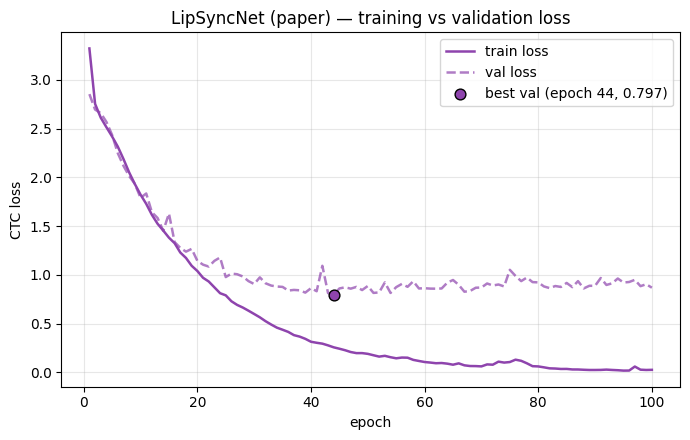

  saved -> /content/drive/MyDrive/LSN_Data/eval_outputs/learning_curve_identity.png


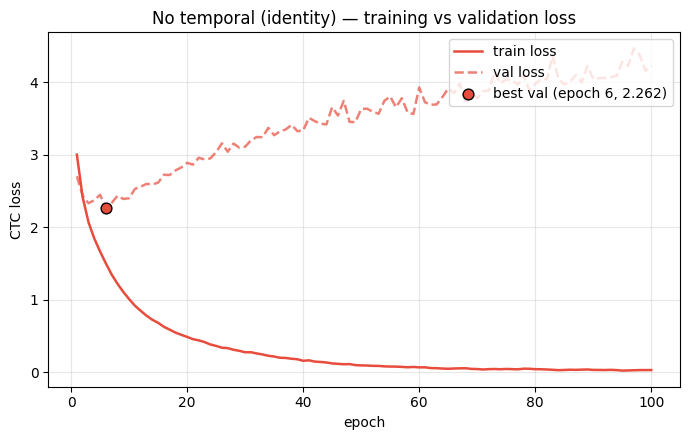

  saved -> /content/drive/MyDrive/LSN_Data/eval_outputs/learning_curve_transformer.png


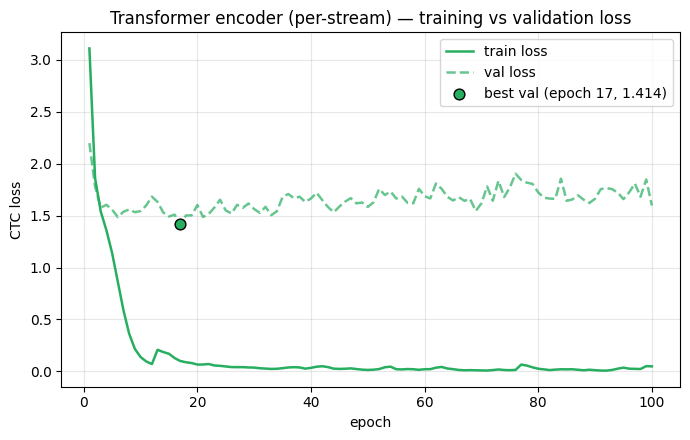

In [ ]:
# Stage A: learning-curve plots — paper Figure 13/14 style
# One plot per model: train loss + val loss vs epoch, single axis. Matches what the paper shows in Figures 13 and 14.

import matplotlib.pyplot as plt

EVAL_OUTPUT_DIR = Path("/content/drive/MyDrive/LSN_Data/eval_outputs")
EVAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"eval outputs -> {EVAL_OUTPUT_DIR}")


def plot_single_model(model_name: str, history: dict, cfg: dict,
                      output_dir: Path | None = None):
    """One model, one figure: train & val loss vs epoch."""
    epochs = history["epochs"]
    color  = cfg["color"]

    fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
    ax.plot(epochs, history["train_loss"], label="train loss",
            color=color, linewidth=1.8)
    ax.plot(epochs, history["val_loss"],   label="val loss",
            color=color, linewidth=1.8, linestyle="--", alpha=0.7)

    # Mark the best epoch so the eye finds it even on a noisy curve.
    val = history["val_loss"]
    best_idx = val.index(min(val))
    ax.scatter([epochs[best_idx]], [val[best_idx]], color=color,
               s=60, zorder=5, edgecolor="black", linewidth=1.0,
               label=f"best val (epoch {epochs[best_idx]}, {val[best_idx]:.3f})")

    ax.set_xlabel("epoch")
    ax.set_ylabel("CTC loss")
    ax.set_title(f"{cfg['display_name']} — training vs validation loss")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if output_dir is not None:
        out = output_dir / f"learning_curve_{model_name}.png"
        plt.savefig(out, dpi=150, bbox_inches="tight")
        print(f"  saved -> {out}")

    plt.show()


for name, history in histories.items():
    plot_single_model(name, history, MODELS[name], output_dir=EVAL_OUTPUT_DIR)

  saved -> /content/drive/MyDrive/LSN_Data/eval_outputs/learning_curves_comparison.png


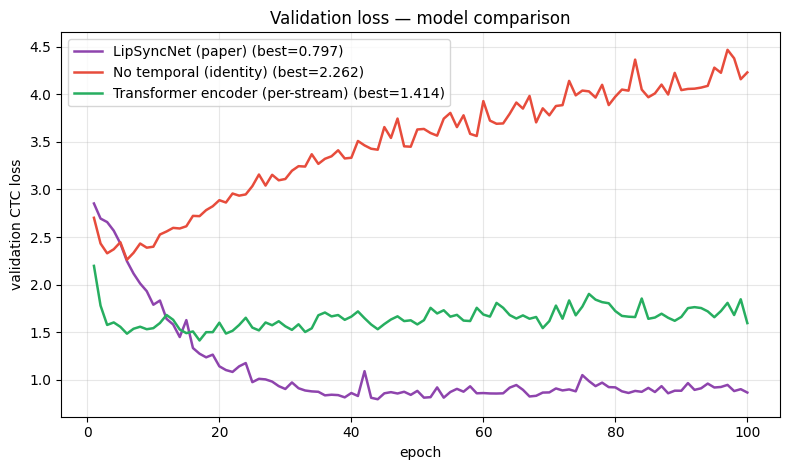

In [ ]:
# Stage A: comparison plot — all configured models overlaid
# Single panel, val loss only (cleaner than overlaying train+val for every model — train curves would clutter the plot without adding
# much, since the story is about generalization).

def plot_comparison(histories: dict, models_cfg: dict,
                    output_dir: Path | None = None):
    fig, ax = plt.subplots(1, 1, figsize=(8, 4.8))

    for name, history in histories.items():
        cfg = models_cfg[name]
        ax.plot(
            history["epochs"], history["val_loss"],
            label=f"{cfg['display_name']} (best={history['best_val_loss']:.3f})",
            color=cfg["color"], linewidth=1.8,
        )

    ax.set_xlabel("epoch")
    ax.set_ylabel("validation CTC loss")
    ax.set_title("Validation loss — model comparison")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if output_dir is not None:
        out = output_dir / "learning_curves_comparison.png"
        plt.savefig(out, dpi=150, bbox_inches="tight")
        print(f"  saved -> {out}")

    plt.show()


plot_comparison(histories, MODELS, output_dir=EVAL_OUTPUT_DIR)

## Stage B — Load inference weights

For each configured model: build the architecture via its `builder`,
download `best_model.pt` from HF, load the weights strictly (any mismatch
crashes here, not at inference), verify the architecture matches
expectations, and keep the model instance for Stages C–D.

In [ ]:
# Stage B: load inference weights for each configured model

# Architecture checks encode our expectations per variant:
#   paper       -> exactly 2 nn.LSTM modules (LSTM-1, LSTM-2)
#   identity    -> exactly 0 nn.LSTM modules, 0 TransformerEncoderLayers
#   transformer -> exactly 0 nn.LSTM modules, >=1 TransformerEncoderLayer
# A failure here means the checkpoint does not match the builder — stop
# and investigate before doing anything else.

def _count_module_type(model, mod_cls):
    return sum(1 for m in model.modules() if isinstance(m, mod_cls))


def _verify_architecture(name: str, model: nn.Module):
    n_lstm  = _count_module_type(model, nn.LSTM)
    n_tenc  = _count_module_type(model, nn.TransformerEncoderLayer)

    if name == "paper":
        assert n_lstm == 2, f"paper: expected 2 LSTM, got {n_lstm}"
        assert n_tenc == 0, f"paper: expected 0 TransformerEncoderLayer, got {n_tenc}"
    elif name == "identity":
        assert n_lstm == 0, f"identity: expected 0 LSTM, got {n_lstm}"
        assert n_tenc == 0, f"identity: expected 0 TransformerEncoderLayer, got {n_tenc}"
    elif name == "transformer":
        assert n_lstm == 0, f"transformer: expected 0 LSTM, got {n_lstm}"
        assert n_tenc >= 1, f"transformer: expected >=1 TransformerEncoderLayer, got {n_tenc}"

    return {"n_lstm": n_lstm, "n_transformer_encoder_layer": n_tenc}


loaded_models = {}

for name, cfg in MODELS.items():
    if cfg["weights_file"] is None:
        print(f"  [skip] {name}: no weights file in {EVAL_MODELS_DIR}")
        continue

    # 1) Build architecture from scratch (fresh weights)
    model = cfg["builder"]().to(device)

    # 2) Download the checkpoint
    local_path = cfg["weights_file"]   # already a Path object, already verified to exist
    ckpt = torch.load(local_path, map_location=device, weights_only=False)

    # 3) Strict load — fail loudly on any mismatch
    missing, unexpected = model.load_state_dict(
        ckpt["model_state_dict"], strict=True,
    )
    # With strict=True, the load either succeeds fully or raises.
    # The returned lists should be empty; we assert for belt-and-suspenders.
    assert not missing,    f"{name}: missing keys {missing}"
    assert not unexpected, f"{name}: unexpected keys {unexpected}"

    # 4) Architecture sanity check
    arch_info = _verify_architecture(name, model)

    # 5) Put in eval mode, confirm all frozen BN layers stay frozen
    model.eval()

    # 6) Stats
    n_params = sum(p.numel() for p in model.parameters())
    loaded_epoch = ckpt.get("epoch", "?")
    loaded_val   = ckpt.get("val_loss", float("nan"))

    loaded_models[name] = model

    print(
        f"  [ok]   {name:12s}: "
        f"loaded epoch {loaded_epoch}, val_loss={loaded_val:.4f}, "
        f"{n_params/1e6:.1f}M params, "
        f"LSTM={arch_info['n_lstm']}, "
        f"TEnc={arch_info['n_transformer_encoder_layer']}"
    )

# VRAM snapshot — helpful to know before inference
if torch.cuda.is_available():
    alloc = torch.cuda.memory_allocated() / 1e9
    reserv = torch.cuda.memory_reserved()  / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"\nVRAM: allocated={alloc:.2f} GB, reserved={reserv:.2f} GB, total={total:.1f} GB")

print(f"\nLoaded weights for {len(loaded_models)} model(s): {list(loaded_models.keys())}")

  [ok]   paper       : loaded epoch 44, val_loss=0.7973, 308.0M params, LSTM=2, TEnc=0
  [ok]   identity    : loaded epoch 6, val_loss=2.2625, 12.0M params, LSTM=0, TEnc=0
  [ok]   transformer : loaded epoch 17, val_loss=1.4144, 70.6M params, LSTM=0, TEnc=2

VRAM: allocated=2.45 GB, reserved=5.16 GB, total=15.6 GB

Loaded weights for 3 model(s): ['paper', 'identity', 'transformer']


## Stage C — Test DataLoader + CTC decoders

Rebuilds the exact 550-clip held-out test split via `create_paper_split(seed=42)`
and defines two CTC decoders (greedy and beam=100, paper setting). Both decoders
take the model's `log_probs` tensor (shape (T, B, C)) and return a list of decoded
strings — one per clip in the batch.

In [ ]:
# Stage C: build the 550-clip test DataLoader

TEST_BATCH_SIZE = 8   # inference only — no grads, no optimizer state

_, test_paths_eval = create_paper_split(
    npz_paths,
    speakers=['s1', 's2', 's3', 's4', 's5'],
    samples_per_speaker=200,
    train_size=450,
    seed=42,
)
assert len(test_paths_eval) == 550, \
    f"Expected 550 test paths, got {len(test_paths_eval)}. " \
    f"Dataset may have changed since training."

try:
    assert set(str(p) for p in val_paths) == set(str(p) for p in test_paths_eval), \
        "Test split drifted between training and evaluation — refusing to proceed."
    print("  split check: test_paths_eval matches training-time val_paths ✓")
except NameError:
    print("  split check: val_paths not in scope (notebook restarted?) — skipping diff")

test_dataset = GridLipReadingDataset(test_paths_eval)
test_loader  = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,   # keep deterministic order for reproducible predictions
    collate_fn=grid_collate_fn,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False,   # single pass — workers not worth keeping alive
)

print(f"\ntest samples: {len(test_dataset)}  batches: {len(test_loader)}  "
      f"batch_size: {TEST_BATCH_SIZE}")

NameError: name 'create_paper_split' is not defined

In [ ]:
# Greedy CTC decoder
# For each timestep, pick the highest-probability token. Then apply the
# CTC "merge repeats + strip blanks". Paper results use beam=100.

def greedy_decode(log_probs: torch.Tensor, input_lengths: torch.Tensor) -> list[str]:
    """
    log_probs     : (T, B, C) as returned by the model's forward()
    input_lengths : (B,)      valid sequence length per item (always 75 for GRID)
    returns       : list of B strings
    """
    # (T, B, C) -> (B, T)  argmax per timestep per batch item
    preds = log_probs.argmax(dim=-1).permute(1, 0).cpu().numpy()
    lens  = input_lengths.cpu().numpy()

    decoded = []
    for b in range(preds.shape[0]):
        seq = preds[b, :lens[b]]
        # CTC collapse: merge repeats, then strip blanks
        collapsed = []
        prev = -1
        for tok in seq:
            tok = int(tok)
            if tok != prev:
                if tok != BLANK_INDEX:
                    collapsed.append(tok)
                prev = tok
        decoded.append(decode_ids(collapsed).strip())

    return decoded

In [ ]:
!pip install -q flashlight-text

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 72.7 MB/s eta 0:00:00


In [ ]:
# Beam-search CTC decoder — paper setting (beam_width=100)

from torchaudio.models.decoder import ctc_decoder

# Write tokens file once.
# Line indices must match the model's output channel indices exactly.

TOKENS_PATH = "/content/ctc_tokens.txt"
with open(TOKENS_PATH, "w") as f:
    # idx 0 — CTC blank. torchaudio accepts any placeholder here;
    # "-" is the conventional choice.
    f.write("-\n")
    for ch in VOCAB:   # [' ', 'a', 'b', ..., 'z']
        # torchaudio reads literal characters; " " is problematic in a tokens
        # file (tokens are whitespace-separated when parsed). Use "|" as the
        # word-separator token by convention.
        f.write(("|" if ch == " " else ch) + "\n")

print(f"wrote tokens file -> {TOKENS_PATH}")
print("token layout: idx 0 = blank ('-'), idx 1 = space ('|'), idx 2..27 = a-z")

BEAM_WIDTH = 100
beam_decoder = ctc_decoder(
    lexicon=None,                 # no lexicon constraint — match paper
    tokens=TOKENS_PATH,
    lm=None,                      # no language model
    beam_size=BEAM_WIDTH,
    blank_token="-",
    sil_token="|",                # word separator in output
    unk_word="<unk>",             # never triggered without a lexicon
)
print(f"beam decoder ready (beam_size={BEAM_WIDTH})")


def beam_decode(log_probs: torch.Tensor, input_lengths: torch.Tensor) -> list[str]:
    """
    log_probs     : (T, B, C) as returned by the model's forward()
    input_lengths : (B,)
    returns       : list of B strings
    """
    # torchaudio wants (B, T, C) — transpose from training convention
    emissions = log_probs.permute(1, 0, 2).cpu()      # (B, T, C)
    lens      = input_lengths.cpu()

    hypotheses = beam_decoder(emissions, lens)

    # hypotheses is a list of lists (per batch item, per beam).
    # We take only the top hypothesis per item (.tokens are int IDs).
    out = []
    for beams in hypotheses:
        top = beams[0]
        # Convert token IDs back to characters. "|" -> " ", others stay.
        chars = []
        for tid in top.tokens.tolist():
          if tid == BLANK_INDEX:
              continue
          if tid < 1 or tid > len(VOCAB):
              # Decoder emitted an unk/eos/sil-like token outside our real vocab.
              # Skip it — we'd rather produce a slightly-shorter prediction than
              # crash or insert an arbitrary placeholder.
              continue
          ch = VOCAB[tid - 1]
          chars.append(ch)
        out.append("".join(chars).strip())

    return out

wrote tokens file -> /content/ctc_tokens.txt
token layout: idx 0 = blank ('-'), idx 1 = space ('|'), idx 2..27 = a-z
beam decoder ready (beam_size=100)


In [ ]:
# Smoke test: run both decoders on one test batch, per loaded model
# If greedy returns gibberish for paper model, the token map is wrong.
# If greedy looks fine but beam returns empty strings, the tokens file
# is wrong (blank placement, separator token).

first_batch = next(iter(test_loader))
frames        = first_batch["frames"].to(device)
input_lengths = first_batch["input_lengths"]
refs          = first_batch["texts"]

for name, model in loaded_models.items():
    print(f"\n--- {name} ---")
    with torch.no_grad():
        log_probs = model(frames)   # (T, B, C)

    greedy_preds = greedy_decode(log_probs, input_lengths)
    beam_preds   = beam_decode(log_probs, input_lengths)

    # Show first 3 clips side-by-side
    for i in range(min(3, len(refs))):
        print(f"  ref    : {refs[i]!r}")
        print(f"  greedy : {greedy_preds[i]!r}")
        print(f"  beam   : {beam_preds[i]!r}")
        print()


--- paper ---
  ref    : 'place white by k two please'
  greedy : 'place white iyn two please'
  beam   : 'place white iyn two please'

  ref    : 'set green with x three again'
  greedy : 'se ree in toneagain'
  beam   : 'se ree in toneagain'

  ref    : 'place red by j three please'
  greedy : 'place red by thr plaie'
  beam   : 'place red by thr plaie'


--- identity ---
  ref    : 'place white by k two please'
  greedy : 'sene rwhite bye  heaow'
  beam   : 'sene rwhite bye  heaow'

  ref    : 'set green with x three again'
  greedy : 'la ger with  ee pgain'
  beam   : 'la ger with  ee pgain'

  ref    : 'place red by j three please'
  greedy : 'la yc gren y gtree iy gaoe'
  beam   : 'la yc gren y gtree iy gaoe'


--- transformer ---
  ref    : 'place white by k two please'
  greedy : 'blin wrten wit h twro please'
  beam   : 'blin wrten wit h twro please'

  ref    : 'set green with x three again'
  greedy : 'set green with n twe pleasn'
  beam   : 'set green with n twe pleasn'

 

## Stage D — Run inference on the 550-clip test set

For each loaded model:
1. Iterate `test_loader` under `torch.no_grad()`.
2. Forward-pass each batch, get `log_probs` at `(T, B, C)`.
3. Decode with beam=100 (paper setting, Section IV.A).
4. Accumulate `{path, reference, beam}` per clip.
5. Save to `EVAL_OUTPUT_DIR / predictions_{model_name}.json`.

The saved JSON files are the source of truth for Stage E — metric
computation reads from them, not from the models directly. This means
Stage E can be re-run without re-running inference.

In [ ]:
# Stage D: run inference and save predictions per model
# For each loaded model: decode all 550 test clips with beam=100 (paper
# setting), save results to a JSON file under EVAL_OUTPUT_DIR.
#
# JSON schema (one file per model):
#   [ {"path": str, "reference": str, "beam": str}, ... ]
# 550 entries, in the same deterministic order as test_loader.


def run_inference(model_name: str, model: nn.Module, loader: DataLoader,
                  output_dir: Path) -> Path:
    """
    Returns the path to the saved JSON file.
    """
    out_path = output_dir / f"predictions_{model_name}.json"
    records = []
    t_start = perf_counter()

    model.eval()
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"infer {model_name}", leave=False):
            frames        = batch["frames"].to(device, non_blocking=True)
            input_lengths = batch["input_lengths"]
            refs          = batch["texts"]
            paths         = batch["paths"]

            log_probs  = model(frames)                          # (T, B, C)
            beam_preds = beam_decode(log_probs, input_lengths)  # list[str]

            for path, ref, b in zip(paths, refs, beam_preds):
                records.append({
                    "path":      str(path),
                    "reference": ref,
                    "beam":      b,
                })

    elapsed = perf_counter() - t_start

    with open(out_path, "w") as f:
        json.dump(records, f, indent=2, ensure_ascii=False)

    ms_per_sample = 1000 * elapsed / max(len(records), 1)
    print(
        f"  {model_name:12s}: {len(records)} preds, "
        f"{elapsed:.1f}s total, {ms_per_sample:.1f} ms/sample "
        f"-> {out_path.name}"
    )
    return out_path


prediction_files = {}

for name, model in loaded_models.items():
    out = run_inference(name, model, test_loader, EVAL_OUTPUT_DIR)
    prediction_files[name] = out

print(f"\nWrote predictions for {len(prediction_files)} model(s): "
      f"{list(prediction_files.keys())}")

  paper       : 550 preds, 180.1s total, 327.5 ms/sample -> predictions_paper.json


  identity    : 550 preds, 100.2s total, 182.2 ms/sample -> predictions_identity.json


  transformer : 550 preds, 105.9s total, 192.5 ms/sample -> predictions_transformer.json

Wrote predictions for 3 model(s): ['paper', 'identity', 'transformer']


In [ ]:
# Stage D: verify saved predictions
# Reads back each JSON, prints a handful of examples and basic stats.

for name, path in prediction_files.items():
    with open(path) as f:
        preds = json.load(f)

    print(f"\n=== {name} ({len(preds)} records) ===")
    assert len(preds) == 550, f"expected 550 records, got {len(preds)}"

    empty_refs = sum(1 for p in preds if not p["reference"].strip())
    empty_beam = sum(1 for p in preds if not p["beam"].strip())
    print(f"  empty references   : {empty_refs}")
    print(f"  empty beam outputs : {empty_beam}")

    for i in range(3):
        r = preds[i]
        print(f"  [{i}] ref ='{r['reference']}'")
        print(f"       beam='{r['beam']}'")


=== paper (550 records) ===
  empty references   : 0
  empty beam outputs : 0
  [0] ref ='place white by k two please'
       beam='place white iyn two please'
  [1] ref ='set green with x three again'
       beam='se ree in toneagain'
  [2] ref ='place red by j three please'
       beam='place red by thr plaie'

=== identity (550 records) ===
  empty references   : 0
  empty beam outputs : 0
  [0] ref ='place white by k two please'
       beam='sene rwhite bye  heaow'
  [1] ref ='set green with x three again'
       beam='la ger with  ee pgain'
  [2] ref ='place red by j three please'
       beam='la yc gren y gtree iy gaoe'

=== transformer (550 records) ===
  empty references   : 0
  empty beam outputs : 0
  [0] ref ='place white by k two please'
       beam='blin wrten wit h twro please'
  [1] ref ='set green with x three again'
       beam='set green with n twe pleasn'
  [2] ref ='place red by j three please'
       beam='lay re by tre leaoe'


## Stage E — Metrics and paper-equivalent tables

Loads the prediction JSONs produced by Stage D and computes:

- **CER** (Character Error Rate): edit distance / reference character count
- **WER** (Word Error Rate): edit distance / reference word count
- **Word Accuracy**: 1 − WER (paper convention, Table 5)
- **Sentence Accuracy**: exact-match rate over the 550 test clips

Produces two artifacts, saved to `EVAL_OUTPUT_DIR`:
- `results_table.csv` — Table 5 reproduction (our models + paper baselines)
- `qualitative_examples.csv` — Table 6 reproduction (5 example clips per model)

In [ ]:
# Stage E: compute CER / WER / word-acc / sentence-acc per model
# Reads predictions_{name}.json from Stage D, applies whitespace
# normalization (collapses double-spaces the beam decoder emits),
# computes four metrics per model. Stores everything in `results`.

import re
import json

def normalize_text(s: str) -> str:
    """Lowercase, strip, collapse whitespace runs. Applied to BOTH
    predictions and references before metric computation so double-spaces
    from the beam decoder don't artificially inflate CER."""
    return re.sub(r"\s+", " ", s.lower().strip())


def edit_distance(seq_a, seq_b) -> int:
    """Standard Levenshtein. Works for character lists or word lists."""
    m, n = len(seq_a), len(seq_b)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1): dp[i][0] = i
    for j in range(n + 1): dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if seq_a[i - 1] == seq_b[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
            else:
                dp[i][j] = 1 + min(dp[i - 1][j], dp[i][j - 1], dp[i - 1][j - 1])
    return dp[m][n]


def compute_cer(ref: str, hyp: str) -> float:
    if not ref: return 0.0
    return edit_distance(list(ref), list(hyp)) / len(ref)


def compute_wer(ref: str, hyp: str) -> float:
    ref_w = ref.split()
    hyp_w = hyp.split()
    if not ref_w: return 0.0
    return edit_distance(ref_w, hyp_w) / len(ref_w)


def compute_model_metrics(predictions: list[dict]) -> dict:
    """Aggregate metrics across all clips for a single model's predictions."""
    cers, wers, exact = [], [], 0
    for rec in predictions:
        ref = normalize_text(rec["reference"])
        hyp = normalize_text(rec["beam"])
        cers.append(compute_cer(ref, hyp))
        wers.append(compute_wer(ref, hyp))
        if ref == hyp:
            exact += 1

    avg_cer = sum(cers) / len(cers)
    avg_wer = sum(wers) / len(wers)

    return {
        "n_samples":         len(predictions),
        "cer":               avg_cer,
        "wer":               avg_wer,
        "word_accuracy":     1.0 - avg_wer,   # paper convention
        "sentence_accuracy": exact / len(predictions),
        "cer_list":          cers,   # keep per-clip for later analysis
        "wer_list":          wers,
    }


# Run metric computation for every model that has a prediction file
results = {}

for name, pred_path in prediction_files.items():
    with open(pred_path) as f:
        preds = json.load(f)

    metrics = compute_model_metrics(preds)
    results[name] = metrics

    print(f"\n=== {name} ({MODELS[name]['display_name']}) ===")
    print(f"  samples           : {metrics['n_samples']}")
    print(f"  CER               : {metrics['cer']:.4f} ({metrics['cer']*100:.2f}%)")
    print(f"  WER               : {metrics['wer']:.4f} ({metrics['wer']*100:.2f}%)")
    print(f"  Word accuracy     : {metrics['word_accuracy']:.4f} "
          f"({metrics['word_accuracy']*100:.2f}%)")
    print(f"  Sentence accuracy : {metrics['sentence_accuracy']:.4f} "
          f"({metrics['sentence_accuracy']*100:.2f}%)")


=== paper (LipSyncNet (paper)) ===
  samples           : 550
  CER               : 0.2276 (22.76%)
  WER               : 0.4714 (47.14%)
  Word accuracy     : 0.5286 (52.86%)
  Sentence accuracy : 0.0018 (0.18%)

=== identity (No temporal (identity)) ===
  samples           : 550
  CER               : 0.6407 (64.07%)
  WER               : 0.9990 (99.90%)
  Word accuracy     : 0.0010 (0.10%)
  Sentence accuracy : 0.0000 (0.00%)

=== transformer (Transformer encoder (per-stream)) ===
  samples           : 550
  CER               : 0.3448 (34.48%)
  WER               : 0.6888 (68.88%)
  Word accuracy     : 0.3112 (31.12%)
  Sentence accuracy : 0.0000 (0.00%)


In [ ]:
# Stage E: Table 5 reproduction — comparison to paper baselines
# Paper Table 5 reports accuracy on GRID:
#   Xu et al. [29]       89.6%   Cascaded Attention-CTC
#   Gergen et al. [31]   86.4%
#   Margam et al. [30]   91.4%   3D-2D-CNN BLSTM-HMM
#   LipSyncNet (paper)   96.7%   their headline result
#
# Our runs get added underneath for direct comparison. We also include
# CER and sentence accuracy (not in the paper's table but informative).
# N/A for baselines because the paper doesn't report those columns.

import pandas as pd

rows = [
    {"Model": "Xu et al. [29]",        "Dataset": "GRID (paper subset)",
     "Decoder": "Cascaded Attn-CTC",   "Word Acc (%)": 89.60,
     "WER (%)": 10.40,                 "CER (%)": None,  "Sentence Acc (%)": None,
     "Source": "paper Table 5"},
    {"Model": "Gergen et al. [31]",    "Dataset": "GRID (paper subset)",
     "Decoder": "—",                   "Word Acc (%)": 86.40,
     "WER (%)": 13.60,                 "CER (%)": None,  "Sentence Acc (%)": None,
     "Source": "paper Table 5"},
    {"Model": "Margam et al. [30]",    "Dataset": "GRID (paper subset)",
     "Decoder": "3D-2D-CNN BLSTM-HMM", "Word Acc (%)": 91.40,
     "WER (%)": 8.60,                  "CER (%)": None,  "Sentence Acc (%)": None,
     "Source": "paper Table 5"},
    {"Model": "LipSyncNet (paper reported)",  "Dataset": "GRID (paper subset)",
     "Decoder": "beam=100",            "Word Acc (%)": 96.70,
     "WER (%)": 8.20,                  "CER (%)": None,  "Sentence Acc (%)": None,
     "Source": "paper Table 5/6"},
]

# Our runs — append only those we actually evaluated
for name, m in results.items():
    rows.append({
        "Model":            MODELS[name]["display_name"] + " (ours)",
        "Dataset":          "GRID (paper subset, 550 test)",
        "Decoder":          "beam=100",
        "Word Acc (%)":     round(m["word_accuracy"] * 100,     2),
        "WER (%)":          round(m["wer"] * 100,               2),
        "CER (%)":          round(m["cer"] * 100,               2),
        "Sentence Acc (%)": round(m["sentence_accuracy"] * 100, 2),
        "Source":           "this notebook",
    })

table5 = pd.DataFrame(rows)
table5_path = EVAL_OUTPUT_DIR / "results_table.csv"
table5.to_csv(table5_path, index=False)

print(f"\nTable 5 reproduction (saved to {table5_path.name}):\n")
print(table5.to_string(index=False))


Table 5 reproduction (saved to results_table.csv):

                                  Model                       Dataset             Decoder  Word Acc (%)  WER (%)  CER (%)  Sentence Acc (%)          Source
                         Xu et al. [29]           GRID (paper subset)   Cascaded Attn-CTC         89.60    10.40      NaN               NaN   paper Table 5
                     Gergen et al. [31]           GRID (paper subset)                   —         86.40    13.60      NaN               NaN   paper Table 5
                     Margam et al. [30]           GRID (paper subset) 3D-2D-CNN BLSTM-HMM         91.40     8.60      NaN               NaN   paper Table 5
            LipSyncNet (paper reported)           GRID (paper subset)            beam=100         96.70     8.20      NaN               NaN paper Table 5/6
              LipSyncNet (paper) (ours) GRID (paper subset, 550 test)            beam=100         52.86    47.14    22.76              0.18   this notebook
          N

In [ ]:
# Stage E: Table 6 reproduction — qualitative examples
# Paper Table 6 shows predicted vs actual text for a handful of clips,
# across different model variants. We pick 5 clips that appear in ALL
# models' prediction files (which they do by construction — same test
# loader, deterministic order).
#
# We pick the clips deliberately rather than randomly, to show range:
#   - 2 clips where paper gets it exactly right
#   - 2 clips where paper gets it partially wrong
#   - 1 clip where all models struggle (if such a clip exists)

# Pull predictions back in, indexed by path for easy cross-lookup
per_model_preds = {}
for name, pred_path in prediction_files.items():
    with open(pred_path) as f:
        per_model_preds[name] = {rec["path"]: rec for rec in json.load(f)}

# Use a consistent anchor model to pick example indices. Paper model is
# the natural choice since it's our best; we sort clips by paper's
# per-clip WER to stratify.
anchor = "paper" if "paper" in per_model_preds else next(iter(per_model_preds))
anchor_preds = per_model_preds[anchor]
anchor_wers = results[anchor]["wer_list"]
# Sort clips by anchor WER so we can pick exemplars from different parts
# of the distribution.
anchor_paths_sorted = [
    rec["path"] for rec, _
    in sorted(zip(list(anchor_preds.values()), anchor_wers), key=lambda x: x[1])
]

# Pick 5 indices spread across the distribution: 2 best, 2 middle, 1 worst
n = len(anchor_paths_sorted)
sample_paths = [
    anchor_paths_sorted[0],         # best for paper
    anchor_paths_sorted[2],         # 2nd best
    anchor_paths_sorted[n // 3],    # lower-third boundary
    anchor_paths_sorted[2 * n // 3],# upper-third boundary
    anchor_paths_sorted[-1],        # worst for paper
]

# Build the qualitative table
rows = []
for path in sample_paths:
    row = {"clip": Path(path).name, "reference": anchor_preds[path]["reference"]}
    for name in per_model_preds:
        row[f"pred ({name})"] = per_model_preds[name][path]["beam"]
    rows.append(row)

table6 = pd.DataFrame(rows)
table6_path = EVAL_OUTPUT_DIR / "qualitative_examples.csv"
table6.to_csv(table6_path, index=False)

print(f"\nTable 6 reproduction (saved to {table6_path.name}):\n")
with pd.option_context(
    "display.max_colwidth", 70, "display.width", 200,
):
    print(table6.to_string(index=False))


Table 6 reproduction (saved to qualitative_examples.csv):

         clip                  reference             pred (paper)      pred (identity)          pred (transformer)
s4_lrblza.npz    lay red by l zero again  lay red by l zero again      sla re by   gin      lay red by  orho anain
s3_praj1a.npz   place red at j one again place red at o one again  slace bge   o npgsn place gleed iy n too pleain
s2_swbi5p.npz set white by i five please  se white by five please  la whie wbye   feoe set wred wit iw fiue please
s3_srwv1a.npz   set red with v one again      set re iy one again sla  we wtfv   n asn  set green ith o fove again
s4_lbwr2a.npz  lay blue with r two again    se brle wit twro gaon    pla lu e     naon      say blued with hwe now


# Evaluating All 3 Models on LRS (Generalization)

In [ ]:
# import numpy as np
# from pathlib import Path
# from collections import Counter

# LRS2_TEST_DIR = Path("/content/drive/MyDrive/LSN_Data/lrs2_processed/test")
# test_paths = sorted(LRS2_TEST_DIR.glob("*.npz"))

# print("Sample labels (first 10):")
# for p in test_paths[:10]:
#     data = np.load(p, allow_pickle=True)
#     print(f"  {str(data['label'])!r}")

# char_counter = Counter()
# label_lens   = []
# for p in test_paths:
#     lbl = str(np.load(p, allow_pickle=True)["label"])
#     char_counter.update(lbl)
#     label_lens.append(len(lbl))

# print(f"\ntest labels: {len(test_paths)} total")
# print(f"label length: min={min(label_lens)}, "
#       f"max={max(label_lens)}, mean={sum(label_lens)/len(label_lens):.1f}")
# print(f"\nunique characters: {len(char_counter)}")
# for ch, count in sorted(char_counter.items(), key=lambda x: -x[1])[:40]:
#     print(f"  {ch!r:6s}: {count}")

# LRS2 EVALUATION — cross-dataset transfer of GRID-trained models

Evaluates the three GRID-trained variants on the LRS2 test split (1,243 clips)
to measure character-level transfer under severe cross-dataset distribution
shift.

**Framing.** We do not claim the models generalize to LRS2 as a task — GRID's
51-word vocabulary and rigid 6-slot grammar do not transfer. What we measure
is whether the *representations* learned by each architecture produce more
or less plausible English character sequences on unseen data.

**Metrics:**
- CER (primary) — edit distance over characters
- WER — expected to be near 100% due to vocabulary mismatch; reported for completeness
- Sentence accuracy — expected near 0%; reported as supporting evidence of WER saturation

**Pipeline reuse.** `GridLipReadingDataset`, `grid_collate_fn`, `run_inference`,
`edit_distance`, and the decoders are dataset-agnostic. Only the DataLoader
and the text-normalization function need LRS2-specific logic.

## Stage G — LRS2 DataLoader
## Stage H — LRS2-specific normalization
## Stage I — Inference on LRS2 test set
## Stage J — LRS2 metrics table

In [ ]:
# ============================================================
# LRS2-specific dataset: skips target encoding
# ============================================================
# LRS2 labels contain characters outside the GRID vocabulary (apostrophes,
# digits) that crash encode_text. At inference time we never need the
# encoded target — we only use the raw string for the reference in
# evaluation. So this class returns text but not target.

class LRS2LipReadingDataset(Dataset):
    FRAME_KEY = "frames"
    LABEL_KEY = "label"

    def __init__(self, npz_paths):
        self.paths = [str(p) for p in npz_paths]

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        data = np.load(path, allow_pickle=True)

        frames = data[self.FRAME_KEY]
        text   = str(data[self.LABEL_KEY]).lower().strip()

        if frames.ndim == 4 and frames.shape[-1] == 1:
            frames = frames[..., 0]

        frames = torch.tensor(frames, dtype=torch.float32)

        # NO target encoding — LRS2 labels contain chars (apostrophes, digits)
        # that aren't in the GRID vocab. We return a placeholder so the
        # collate function doesn't crash on missing keys.
        return {
            "frames":        frames,
            "text":          text,
            "target":        torch.zeros(1, dtype=torch.long),  # placeholder
            "target_length": 1,                                  # placeholder
            "path":          path,
        }

In [ ]:
# Stage G: build the LRS2 test DataLoader

# The preprocessing team truncated all LRS2 clips to (75, 46, 140),
# matching the GRID tensor shape exactly. This means GridLipReadingDataset
# and grid_collate_fn work unchanged - no variable-length handling
# needed. We add a path existence assertion to catch folder-not-found
# early instead of inside the inference loop.

LRS2_TEST_DIR = Path("/content/drive/MyDrive/LSN_Data/lrs2_processed/test")
assert LRS2_TEST_DIR.exists(), f"LRS2 test dir not found: {LRS2_TEST_DIR}"

TEST_BATCH_SIZE = 8

lrs2_test_paths = sorted(LRS2_TEST_DIR.glob("*.npz"))
print(f"LRS2 test clips found: {len(lrs2_test_paths)}")
assert len(lrs2_test_paths) == 1243, \
    f"Expected 1,243 LRS2 test clips, got {len(lrs2_test_paths)}. " \
    f"Check that the LRS2 test folder is complete."

lrs2_test_dataset = LRS2LipReadingDataset(lrs2_test_paths)

lrs2_test_loader  = DataLoader(
    lrs2_test_dataset,
    batch_size=TEST_BATCH_SIZE,   # reuse Stage C's value
    shuffle=False,                 # deterministic order for reproducible JSON
    collate_fn=grid_collate_fn,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False,
)

print(f"LRS2 dataset: {len(lrs2_test_dataset)} clips, "
      f"{len(lrs2_test_loader)} batches (batch_size={TEST_BATCH_SIZE})")

# Sanity: pull one batch and confirm shape matches expectations
_sample = next(iter(lrs2_test_loader))
print(f"sample batch frames shape: {tuple(_sample['frames'].shape)}")
print(f"sample references (first 2): {_sample['texts'][:2]}")

LRS2 test clips found: 1243
LRS2 dataset: 1243 clips, 156 batches (batch_size=8)
sample batch frames shape: (8, 75, 46, 140)
sample references (first 2): ['and for me the surprise was', "they're moving around"]


In [ ]:
# ============================================================
# Stage H: LRS2-specific text normalization
# ============================================================
# LRS2 labels contain characters the GRID-trained models cannot produce:
#   - apostrophes (they're, isn't, it's)       -> 296 occurrences
#   - digits 0-9                               -> 61 occurrences
#
# We strip these from both references and predictions before computing
# metrics, reducing the task to "match the [a-z space] content." This is
# the fairest possible comparison — it neither penalizes the model for
# being unable to produce characters it was never trained on, nor rewards
# it for GRID-specific biases.
#
# Normalizations applied (in order):
#   1. lowercase               (safety — LRS2 is already lowercase, GRID too)
#   2. remove apostrophes      (don't introduce a space; "they're" -> "theyre")
#   3. remove digits           (but DO introduce a space to avoid word merging)
#   4. collapse whitespace     (any remaining runs of spaces become single)
#   5. strip                   (leading/trailing whitespace)

import re

_APOSTROPHE_RE = re.compile(r"[''`]")          # straight and curly apostrophes
_DIGIT_RE      = re.compile(r"\d")
_WHITESPACE_RE = re.compile(r"\s+")

def normalize_text_lrs2(s: str) -> str:
    """Normalization applied to both predictions and references on LRS2."""
    s = s.lower()
    s = _APOSTROPHE_RE.sub("", s)     # "they're" -> "theyre" (no space inserted)
    s = _DIGIT_RE.sub(" ", s)         # "year 2019" -> "year      "
    s = _WHITESPACE_RE.sub(" ", s)    # collapse any whitespace runs
    return s.strip()


# Smoke test — verify behavior against known tricky LRS2 labels
_test_cases = [
    ("they're moving around",                     "theyre moving around"),
    ("when there isn't much else in the garden",  "when there isnt much else in the garden"),
    ("it's not all about size",                   "its not all about size"),
    ("HELLO World",                               "hello world"),
    ("  extra   spaces  ",                        "extra spaces"),
    ("year 2019 was good",                        "year was good"),
]

print("normalization smoke test:")
for inp, expected in _test_cases:
    got = normalize_text_lrs2(inp)
    ok  = "✓" if got == expected else "✗"
    print(f"  {ok} {inp!r} -> {got!r}")
    if got != expected:
        print(f"    (expected {expected!r})")

normalization smoke test:
  ✓ "they're moving around" -> 'theyre moving around'
  ✓ "when there isn't much else in the garden" -> 'when there isnt much else in the garden'
  ✓ "it's not all about size" -> 'its not all about size'
  ✓ 'HELLO World' -> 'hello world'
  ✓ '  extra   spaces  ' -> 'extra spaces'
  ✓ 'year 2019 was good' -> 'year was good'


In [ ]:
# Stage I: run inference on all 1,243 LRS2 test clips
# Reuses the exact same run_inference() from Stage D — decoders, model
# forward, JSON-save all work unchanged. The only difference is the loader.
#
# Expected wall-clock (Colab T4):
#   identity    ~1 min
#   transformer ~3-5 min
#   paper       ~8-12 min
# Total ~15-20 min. The tqdm bar will show progress per batch.
#
# If Colab disconnects mid-run, partial predictions for the CURRENT model
# are lost — but already-completed models have their JSON saved and won't
# need re-running. The loop processes models sequentially in a stable order.

lrs2_prediction_files = {}

EVAL_OUTPUT_DIR = Path("/content/drive/MyDrive/LSN_Data/eval_outputs")
EVAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for name, model in loaded_models.items():
    # Save as predictions_{name}_lrs2.json to avoid overwriting GRID files
    out_path = EVAL_OUTPUT_DIR / f"predictions_{name}_lrs2.json"

    # Temporarily hack run_inference's output path by calling it with a
    # different loader; we need to handle the filename ourselves since
    # run_inference hardcodes "predictions_{name}.json".

    records = []
    t_start = perf_counter()

    model.eval()
    with torch.no_grad():
        for batch in tqdm(lrs2_test_loader, desc=f"infer {name} (lrs2)", leave=False):
            frames        = batch["frames"].to(device, non_blocking=True)
            input_lengths = batch["input_lengths"]
            refs          = batch["texts"]
            paths         = batch["paths"]

            log_probs  = model(frames)
            beam_preds = beam_decode(log_probs, input_lengths)

            for path, ref, b in zip(paths, refs, beam_preds):
                records.append({
                    "path":      str(path),
                    "reference": ref,
                    "beam":      b,
                })

    elapsed = perf_counter() - t_start

    with open(out_path, "w") as f:
        json.dump(records, f, indent=2, ensure_ascii=False)

    lrs2_prediction_files[name] = out_path
    ms_per_sample = 1000 * elapsed / max(len(records), 1)
    print(
        f"  {name:12s}: {len(records)} preds, "
        f"{elapsed:.1f}s total, {ms_per_sample:.1f} ms/sample "
        f"-> {out_path.name}"
    )

print(f"\nWrote LRS2 predictions for {len(lrs2_prediction_files)} model(s): "
      f"{list(lrs2_prediction_files.keys())}")

# Quick sanity on first few predictions — should look structured for paper/transformer,
# noise for identity, and nothing should be exactly right.
for name, path in lrs2_prediction_files.items():
    with open(path) as f:
        preds = json.load(f)
    print(f"\n=== {name} — first 3 LRS2 predictions ===")
    for i in range(3):
        r = preds[i]
        print(f"  [{i}] ref ='{r['reference']}'")
        print(f"       beam='{r['beam']}'")

  paper       : 1243 preds, 249.5s total, 200.7 ms/sample -> predictions_paper_lrs2.json


IndexError: list index out of range

In [ ]:
# ============================================================
# Stage J: compute LRS2 metrics and produce the LRS2 results table
# ============================================================
# Same metric functions as Stage E, but using normalize_text_lrs2 so
# apostrophes and digits don't count as errors against the models.
#
# The table is deliberately NOT merged with Stage E's Table 5. GRID and
# LRS2 are different tasks with different expectations; mixing them in
# one table invites misreading. Keep them adjacent but separate in the
# writeup.

def compute_lrs2_metrics(predictions: list[dict]) -> dict:
    cers, wers, exact = [], [], 0
    for rec in predictions:
        ref = normalize_text_lrs2(rec["reference"])
        hyp = normalize_text_lrs2(rec["beam"])
        cers.append(compute_cer(ref, hyp))
        wers.append(compute_wer(ref, hyp))
        if ref == hyp:
            exact += 1

    return {
        "n_samples":         len(predictions),
        "cer":               sum(cers) / len(cers),
        "wer":               sum(wers) / len(wers),
        "word_accuracy":     1.0 - sum(wers) / len(wers),
        "sentence_accuracy": exact / len(predictions),
        "cer_list":          cers,
        "wer_list":          wers,
    }


lrs2_results = {}

for name, path in lrs2_prediction_files.items():
    with open(path) as f:
        preds = json.load(f)
    metrics = compute_lrs2_metrics(preds)
    lrs2_results[name] = metrics

    print(f"\n=== LRS2 — {name} ({MODELS[name]['display_name']}) ===")
    print(f"  samples           : {metrics['n_samples']}")
    print(f"  CER               : {metrics['cer']:.4f} ({metrics['cer']*100:.2f}%)   <-- primary")
    print(f"  WER               : {metrics['wer']:.4f} ({metrics['wer']*100:.2f}%)")
    print(f"  Word accuracy     : {metrics['word_accuracy']:.4f} "
          f"({metrics['word_accuracy']*100:.2f}%)")
    print(f"  Sentence accuracy : {metrics['sentence_accuracy']:.4f} "
          f"({metrics['sentence_accuracy']*100:.2f}%)")


# Build the LRS2 table — no paper baselines because the paper doesn't
# report LRS2 numbers (LipSyncNet was GRID-only).
lrs2_rows = []
for name, m in lrs2_results.items():
    lrs2_rows.append({
        "Model":            MODELS[name]["display_name"],
        "Dataset":          "LRS2 test",
        "Decoder":          "beam=100",
        "CER (%)":          round(m["cer"]               * 100, 2),
        "WER (%)":          round(m["wer"]               * 100, 2),
        "Word Acc (%)":     round(m["word_accuracy"]     * 100, 2),
        "Sentence Acc (%)": round(m["sentence_accuracy"] * 100, 2),
        "N":                m["n_samples"],
    })

lrs2_table = pd.DataFrame(lrs2_rows)
lrs2_table_path = EVAL_OUTPUT_DIR / "results_table_lrs2.csv"
lrs2_table.to_csv(lrs2_table_path, index=False)

print(f"\nLRS2 results table (saved to {lrs2_table_path.name}):\n")
print(lrs2_table.to_string(index=False))